In [3829]:
import pandas as pd

In [3830]:
import numpy as np

In [3831]:
import os
os.chdir("/Users/melyndacelani/Desktop/Capstone_Data")


In [3832]:
#import the data for 2017-2018

alq_18 = pd.read_sas("ALQ_J.XPT")
demo_18 = pd.read_sas("DEMO_J.XPT")
dpq_18 = pd.read_sas("DPQ_J.XPT")
duq_18 = pd.read_sas("DUQ_J.XPT")
mcq_18 = pd.read_sas("MCQ_J.XPT")
slq_18 = pd.read_sas("SLQ_J.XPT")
smq_18 = pd.read_sas("SMQ_J.XPT")

In [3833]:
#make sure each separate imported data set has the "SEQN" column for joining

for name, df in {
    "demo": demo_18,
    "dpq": dpq_18,
    "alq": alq_18,
    "duq": duq_18,
    "mcq": mcq_18,
    "slq": slq_18,
    "smq": smq_18
}.items():
    print(name, "SEQN" in df.columns)

demo True
dpq True
alq True
duq True
mcq True
slq True
smq True


In [3834]:
#make a copy of the "demo" data table for a template
data = demo_18.copy()

#merge all of the data, left join on "SEQN" to make one table for 2017-2018
data = data.merge(dpq_18, on="SEQN", how="left")
data = data.merge(alq_18, on="SEQN", how="left")
data = data.merge(duq_18, on="SEQN", how="left")
data = data.merge(mcq_18, on="SEQN", how="left")
data = data.merge(slq_18, on="SEQN", how="left")
data = data.merge(smq_18, on="SEQN", how="left")

In [3835]:
#check number of rows and columns
data.shape

(9254, 226)

In [3836]:
#look at the head
data.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,SMQ848,SMQ852Q,SMQ852U,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,SMAQUEX2
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,NaN,NaN,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [3837]:
#look for missing data
data.isnull().sum().sort_values(ascending=False).head(20)

SMQ665B    9253
MCQ230D    9253
SMQ665D    9252
SMQ665A    9251
SMQ665C    9250
MCQ510B    9248
DUQ320     9246
MCQ230C    9245
MCD240C    9245
MCQ510E    9242
SMQ661     9240
MCQ510C    9230
DUD380F    9229
DUQ360     9220
DUQ380C    9220
SMD630     9212
MCQ510D    9204
DUQ380A    9200
DUQ380B    9200
RHD018     9199
dtype: int64

In [3838]:
#find the PHQ-9 (Patient Health Questionnaire-9) variables
data.filter(like="DPQ").columns

Index(['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070',
       'DPQ080', 'DPQ090', 'DPQ100'],
      dtype='object')

In [3839]:
#create depression severity score
phq_items = [
    "DPQ010", "DPQ020", "DPQ030", "DPQ040", "DPQ050", "DPQ060", "DPQ070",
       "DPQ080", "DPQ090"
]

#for every PHQ symptom question replace response codes 7 & 9 with missing values
#in the NHANES data 7 = refused to answer & 9 = don't know
for col in phq_items:
    data[col] = data[col].replace({7: np.nan, 9: np.nan})

#calculate each patient's total PHQ-9 score by adding together responses across the PHQ items
data["PHQ9_TOTAL"] = data[phq_items].sum(axis=1, skipna=True)

In [3840]:
#look at distribution
data["PHQ9_TOTAL"].describe()

count    9.254000e+03
mean     1.784309e+00
std      3.540192e+00
min      0.000000e+00
25%      0.000000e+00
50%      4.857845e-78
75%      2.000000e+00
max      2.500000e+01
Name: PHQ9_TOTAL, dtype: float64

In [3841]:
#round the PHQ-9 score to the nearest whole number
data["PHQ9_TOTAL"] = data["PHQ9_TOTAL"].round(0)

<Axes: >

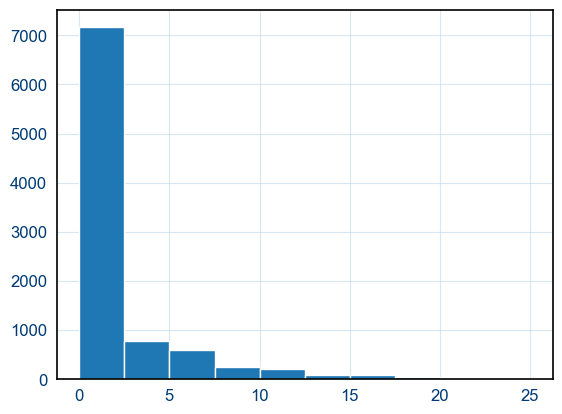

In [3842]:
#look at distribution histogram
data["PHQ9_TOTAL"].hist()

In [3843]:
#create a binary depression outcome greater or equal to 10 (threshold for moderate depression)
data["DEPRESSED"] = (data["PHQ9_TOTAL"] >= 10).astype(int)

In [3844]:
#check class balance
data["DEPRESSED"].value_counts()

DEPRESSED
0    8793
1     461
Name: count, dtype: int64

In [3845]:
#percentage of patients who are depressed vs not depressed
data["DEPRESSED"].value_counts(normalize=True)

DEPRESSED
0    0.950184
1    0.049816
Name: proportion, dtype: float64

In [3846]:
#create new column called "Function_Impairement" & put values from DPQ100 in it
data["FUNCTION_IMPAIRMENT"] = data["DPQ100"]

In [3847]:
#use just age and sex as variables
features = [
    "RIDAGEYR", #age
    "RIAGENDR", #sex
]

#create new dataset with just features above & remove rows with missing values
model_df = data[features + ["DEPRESSED"]].dropna()

print(model_df.shape)

(9254, 3)


In [3848]:
#create X (features) and y (target) variables
X = model_df[features]
y = model_df["DEPRESSED"]

In [3849]:
#look at predictor variables
X.describe()

,RIDAGEYR,RIAGENDR
count,9.254000e+03,9254.000000
mean,3.433423e+01,1.507564
std,2.550028e+01,0.499970
min,5.397605e-79,1.000000
25%,1.100000e+01,1.000000
50%,3.100000e+01,2.000000
75%,5.800000e+01,2.000000
max,8.000000e+01,2.000000


In [3850]:
#look at head of predictor variables
X.head()

,RIDAGEYR,RIAGENDR
0,2.0,2.0
1,2.0,1.0
2,66.0,2.0
3,18.0,1.0
4,13.0,1.0


In [3851]:
#import train_test_split from sklearn
from sklearn.model_selection import train_test_split

#create X (features) & y (target) variables
X = model_df[features]
y = model_df["DEPRESSED"]

#split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [3852]:
#check class balances
y_train.value_counts(normalize=True)

DEPRESSED
0    0.950155
1    0.049845
Name: proportion, dtype: float64

In [3853]:
#check class balances
y_test.value_counts(normalize=True)

DEPRESSED
0    0.950297
1    0.049703
Name: proportion, dtype: float64

In [3854]:
#rows & columns check
X_train.shape

(7403, 2)

In [3855]:
#rows & columns check
X_test.shape

(1851, 2)

In [3856]:
#import LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression

#build a LogisticRegression model
lm_model = LogisticRegression(max_iter=1000)

#fit the LogisticRegression model
lm_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [3857]:
#import evaluation metrics from sklearn
from sklearn.metrics import roc_auc_score, classification_report

#evaluate model performance
lm_pred = lm_model.predict_proba(X_test)[:,1]

#get AUROC
roc_auc_score(y_test, lm_pred)

np.float64(0.6869392194181476)

In [3858]:
#Identify sleep variables
slq_18.columns

Index(['SEQN', 'SLQ300', 'SLQ310', 'SLD012', 'SLQ320', 'SLQ330', 'SLD013',
       'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120'],
      dtype='object')

In [3859]:
#explore the SLQ320 column
data["SLQ320"].head()

0         NaN
1         NaN
2    b'23:00'
3    b'00:30'
4         NaN
Name: SLQ320, dtype: object

In [3860]:
#explore the SLQ320 column
data["SLQ320"].unique()

array([nan, b'23:00', b'00:30', b'22:30', b'01:00', b'00:00', b'22:00',
       b'23:30', b'21:00', b'20:00', b'01:30', b'22:45', b'03:00',
       b'21:30', b'02:00', b'19:00', b'04:00', b'23:50', b'99999',
       b'20:30', b'02:30', b'06:30', b'07:00', b'', b'23:20', b'05:00',
       b'06:00', b'07:30', b'12:00', b'10:00', b'11:00', b'22:10',
       b'03:30', b'19:30', b'15:00', b'08:00', b'23:15', b'08:30',
       b'18:00', b'00:40', b'22:15', b'21:15', b'17:30', b'20:10',
       b'23:45', b'18:30', b'17:00', b'09:00', b'21:40', b'16:00',
       b'23:35', b'77777', b'14:00', b'00:15', b'05:30', b'00:20',
       b'04:30', b'21:45', b'13:30', b'21:10', b'02:45', b'20:45'],
      dtype=object)

In [3861]:
#keep sleep duration, daytime fatigue and sleep medication use
sleep_features = [
    "SLD012", #sleep duration
    "SLQ040", #daytime sleepiness
    "SLQ120"  # sleep medication
]

In [3862]:
#add age, gender & sleep features to features list
features = [
    "RIDAGEYR", #age
    "RIAGENDR"  #sex
] + sleep_features #sleep features above

In [3863]:
#build a modeling dataset adding target variable "depressed"
model_df = data[features + ["DEPRESSED"]].dropna()

In [3864]:
#check columns and rows
model_df.shape

(6113, 6)

In [3865]:
#import train_test_split from sklearn
from sklearn.model_selection import train_test_split

#build features and target variables
X = model_df[features]
y = model_df["DEPRESSED"]

#split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [3866]:
#look at what type of data is in X_train
X_train.dtypes

RIDAGEYR    float64
RIAGENDR    float64
SLD012      float64
SLQ040      float64
SLQ120      float64
dtype: object

In [3867]:
#import LogisticRegression model from sklearn
from sklearn.linear_model import LogisticRegression

#build a Logistic Regression model
lm_model2 = LogisticRegression(max_iter=1000)

#fit the Logistic Regression model
lm_model2.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [3868]:
#import evaluation metrics from sklearn
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

#get probabilities and roc score
lm_pred2 = lm_model2.predict_proba(X_test)[:,1]
auc_sleep = roc_auc_score(y_test, lm_pred2)

#print roc score
auc_sleep

np.float64(0.7391193488280868)

In [3869]:
#convert probabilities into 0 or 1
lm_pred2 = (lm_pred2 >= 0.5).astype(int)

#build confusion matrix
confusion_matrix(y_test, lm_pred2)

array([[1132,    1],
       [  90,    0]])

In [3870]:
#print a classification report
print(classification_report(y_test, lm_pred2))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1133
           1       0.00      0.00      0.00        90

    accuracy                           0.93      1223
   macro avg       0.46      0.50      0.48      1223
weighted avg       0.86      0.93      0.89      1223



In [3871]:
#build a logistic coefficients list & sort from lowest to highest
coef_df = pd.Series(
    lm_model2.coef_[0], #predicting class "1" (DEPRESSED)
    index=features #label
).sort_values() #sort

#print the logistic coefficients list, higher the value/higher probability of depression
coef_df

SLD012     -0.019872
RIDAGEYR    0.002377
SLQ040      0.113483
RIAGENDR    0.327374
SLQ120      0.533388
dtype: float64

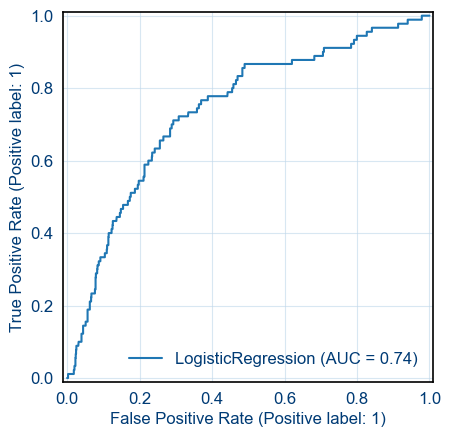

In [3872]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

#generate a ROC Curve Display and save to folder
RocCurveDisplay.from_estimator(lm_model2, X_test, y_test)
plt.savefig("roc_curve.png", dpi=300)

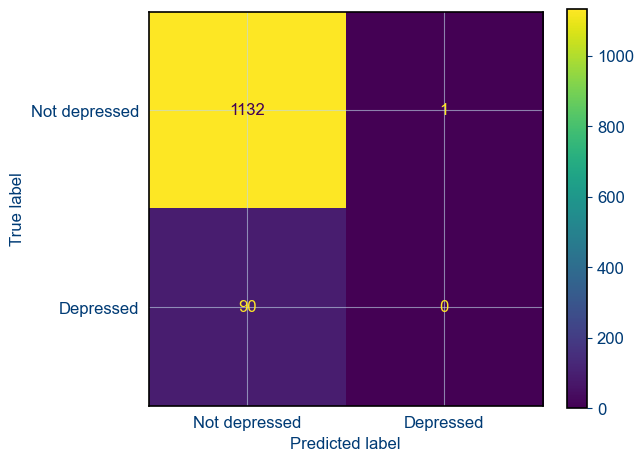

In [3873]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# If you already have predicted probabilities:
lm_pred2 = (lm_pred2 >= 0.5).astype(int)

#assign variables & labels
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, lm_pred2,
    display_labels=["Not depressed", "Depressed"],
    values_format="d"
)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [3874]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

num_features = features  #numeric features

#preprocess data pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features)
    ],
    remainder="drop"
)

#add preprocess pipeline to model
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

#show pipeline
clf

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RIDAGEYR', 'RIAGENDR',
                                                   'SLD012', 'SLQ040',
                                                   'SLQ120'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [3875]:
#GRABBED THE PRESCRIPTION DATA, CHECK IT OUT
df_rx = pd.read_sas("RXQ_RX_J.XPT")
df_rx.head()

,SEQN,RXDUSE,RXDDRUG,RXDDRGID,RXQSEEN,RXDDAYS,RXDRSC1,RXDRSC2,RXDRSC3,RXDRSD1,RXDRSD2,RXDRSD3,RXDCOUNT
0,93703.0,2.0,b'',b'',NaN,NaN,b'',b'',b'',b'',b'',b'',NaN
1,93704.0,2.0,b'',b'',NaN,NaN,b'',b'',b'',b'',b'',b'',NaN
2,93705.0,1.0,b'ENALAPRIL; HYDROCHLOROTHIAZIDE',b'd03740',1.0,5475.0,b'I10',b'',b'',b'Essential (primary) hypertension',b'',b'',3.0
3,93705.0,1.0,b'MELOXICAM',b'd04532',1.0,61.0,b'M06.9',b'',b'',"b'Rheumatoid arthritis, unspecified'",b'',b'',3.0
4,93705.0,1.0,b'OMEPRAZOLE',b'd00325',1.0,3650.0,b'R12',b'',b'',b'Heartburn',b'',b'',3.0


In [3876]:
#make prescriptions readable
df_rx['RXDDRUG'] = df_rx['RXDDRUG'].str.decode('utf-8')
df_rx['RXDDRUG'] = df_rx['RXDDRUG'].str.upper()

In [3877]:
#identify the antidepressants
def classify_antidepressant(drug):
    if pd.isna(drug):
        return None

    drug = drug.upper()

    ssri = ['FLUOXETINE','SERTRALINE','CITALOPRAM','ESCITALOPRAM','PAROXETINE','FLUVOXAMINE']
    snri = ['VENLAFAXINE','DESVENLAFAXINE','DULOXETINE','LEVOMILNACIPRAN']
    tca = ['AMITRIPTYLINE','NORTRIPTYLINE','IMIPRAMINE','DESIPRAMINE','CLOMIPRAMINE','DOXEPIN']
    atypical = ['BUPROPION','MIRTAZAPINE','TRAZODONE','VILAZODONE','VORTIOXETINE']
    
    if any(d in drug for d in ssri):
        return 'SSRI'
    if any(d in drug for d in snri):
        return 'SNRI'
    if any(d in drug for d in tca):
        return 'TCA'
    if any(d in drug for d in atypical):
        return 'ATYPICAL'
    
    return None

df_rx['AD_CLASS'] = df_rx['RXDDRUG'].apply(classify_antidepressant)

In [3878]:
#keep only the antidepressants
df_ad = df_rx[df_rx['AD_CLASS'].notnull()]

In [3879]:
#only keep people taking one antidepressant
ad_counts = df_ad.groupby('SEQN')['AD_CLASS'].nunique().reset_index()
ad_counts = ad_counts[ad_counts['AD_CLASS'] == 1]

single_class_ids = ad_counts['SEQN']

df_ad_single = df_ad[df_ad['SEQN'].isin(single_class_ids)]

df_treatment = df_ad_single[['SEQN','AD_CLASS']].drop_duplicates()

In [3880]:
#merge prescriptions with main cdc dataset
data = data.merge(df_treatment, on='SEQN', how='inner')

data.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,SMAQUEX2,PHQ9_TOTAL,DEPRESSED,FUNCTION_IMPAIRMENT,AD_CLASS
0,93709.0,10.0,2.0,2.0,75.0,NaN,4.0,4.0,1.0,NaN,...,5.397605e-79,1.0,5.397605e-79,1.0,5.397605e-79,1.0,0.0,0,NaN,SSRI
1,93715.0,10.0,2.0,1.0,71.0,NaN,5.0,7.0,2.0,NaN,...,2.000000e+00,1.0,5.397605e-79,1.0,5.397605e-79,1.0,4.0,0,5.397605e-79,SSRI
2,93740.0,10.0,2.0,1.0,72.0,NaN,4.0,4.0,1.0,NaN,...,NaN,1.0,5.397605e-79,2.0,NaN,1.0,4.0,0,5.397605e-79,SSRI
3,93742.0,10.0,2.0,1.0,72.0,NaN,4.0,4.0,2.0,NaN,...,NaN,2.0,NaN,2.0,NaN,1.0,2.0,0,5.397605e-79,SSRI
4,93767.0,10.0,2.0,1.0,61.0,NaN,2.0,2.0,1.0,NaN,...,5.397605e-79,2.0,NaN,2.0,NaN,1.0,3.0,0,5.397605e-79,SSRI


In [3881]:
#show column labels
df_treatment.columns

Index(['SEQN', 'AD_CLASS'], dtype='object')

In [3882]:
#show first five
df_treatment.head()

,SEQN,AD_CLASS
12,93709.0,SSRI
24,93715.0,SSRI
78,93740.0,SSRI
87,93742.0,SSRI
141,93767.0,SSRI


In [3883]:
#make seqn types match (integers)
data['SEQN'] = data['SEQN'].astype(int)
df_treatment['SEQN'] = df_treatment['SEQN'].astype(int)

In [3884]:
#merge treatment class into the main dataset
data = data.merge(df_treatment, on='SEQN', how='inner')

In [3885]:
#confirm the column exists
print(data.columns)
print(data.shape)

# Case 1: already have AD_CLASS
if "AD_CLASS" in data.columns:
    pass

# Case 2: merge-created columns exist, rebuild AD_CLASS from them
elif "AD_CLASS_x" in data.columns or "AD_CLASS_y" in data.columns:
    if "AD_CLASS_x" in data.columns and "AD_CLASS_y" in data.columns:
        data["AD_CLASS"] = data["AD_CLASS_x"].combine_first(data["AD_CLASS_y"])
    elif "AD_CLASS_x" in data.columns:
        data["AD_CLASS"] = data["AD_CLASS_x"]
    elif "AD_CLASS_y" in data.columns:
        data["AD_CLASS"] = data["AD_CLASS_y"]

# Case 3: no AD_CLASS at all, merge df_treatment again
else:
    data["SEQN"] = data["SEQN"].astype(int)
    df_treatment["SEQN"] = df_treatment["SEQN"].astype(int)
    data = data.merge(df_treatment, on="SEQN", how="inner")

# Clean up duplicate columns if they exist
cols_to_drop = [c for c in ["AD_CLASS_x", "AD_CLASS_y"] if c in data.columns]
if len(cols_to_drop) > 0:
    data = data.drop(columns=cols_to_drop)

print("Final AD columns:", [c for c in data.columns if "AD_CLASS" in c])
print(data["AD_CLASS"].value_counts())
print(data.shape)


Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM',
       ...
       'SMQ900', 'SMQ905', 'SMQ910', 'SMQ915', 'SMAQUEX2', 'PHQ9_TOTAL',
       'DEPRESSED', 'FUNCTION_IMPAIRMENT', 'AD_CLASS_x', 'AD_CLASS_y'],
      dtype='object', length=231)
(614, 231)
Final AD columns: ['AD_CLASS']
AD_CLASS
SSRI        362
ATYPICAL    115
SNRI         92
TCA          45
Name: count, dtype: int64
(614, 230)


In [3886]:
# Keep the final AD_CLASS and drop merge leftovers
cols_to_drop = [c for c in ["AD_CLASS_x", "AD_CLASS_y"] if c in data.columns]
data = data.drop(columns=cols_to_drop)

# Sanity check
data[["SEQN", "AD_CLASS"]].head(), data["AD_CLASS"].value_counts()

(    SEQN AD_CLASS
 0  93709     SSRI
 1  93715     SSRI
 2  93740     SSRI
 3  93742     SSRI
 4  93767     SSRI,
 AD_CLASS
 SSRI        362
 ATYPICAL    115
 SNRI         92
 TCA          45
 Name: count, dtype: int64)

In [3887]:
#map treatment class labels
treat_map = {"ATYPICAL": 0, "SNRI": 1, "SSRI": 2, "TCA": 3}

#replace string labels with mapped labels
data["treatment"] = data["AD_CLASS"].map(treat_map).astype(int)

In [3888]:
#assign outcome variable as binary 1/0
Y = data["DEPRESSED"].astype(int).values

#assign treatment variable as mapped values
T = data["treatment"].values

In [3889]:
#name predictors
X_cols=["RIDAGEYR", "RIAGENDR", "RIDRETH1"]

#select only predictor columns from data
X = data[X_cols].copy()

In [3890]:
#Handle missing rows simply
model_df = data[["DEPRESSED", "treatment"] + X_cols].dropna().copy()

In [3891]:
#convert DEPRESSED column values to integers 1/0
Y = model_df["DEPRESSED"].astype(int).values

#make sure treatment values are integers
T = model_df["treatment"].astype(int).values

#select only columns listed in X_cols
X = model_df[X_cols].values

In [3892]:
#check rows/columns & count each treatment sample
model_df.shape,pd.Series(T).value_counts()

((614, 5),
 2    362
 0    115
 1     92
 3     45
 Name: count, dtype: int64)

In [3893]:
##Going to remove TCA for cleaner estimates and lower variance
data = data[data["AD_CLASS"] != "TCA"].copy()

#Check new counts
data["AD_CLASS"].value_counts(), data.shape

(AD_CLASS
 SSRI        362
 ATYPICAL    115
 SNRI         92
 Name: count, dtype: int64,
 (569, 231))

In [3894]:
#Remap the treatment codes
treat_map = {"ATYPICAL": 0, "SNRI": 1, "SSRI": 2}
data["treatment"] = data["AD_CLASS"].map(treat_map).astype(int)

#check counts
data["treatment"].value_counts()

treatment
2    362
0    115
1     92
Name: count, dtype: int64

In [3895]:
#Define Outcome Y
Y = data["DEPRESSED"].astype(int).values

#define treatment T
T = data["treatment"].values

In [3896]:
#Define Covariates (start simple)
X_cols = ["RIDAGEYR", "RIAGENDR", "RIDRETH1"]

#only select assigned columns & name model_df
model_df = data[["DEPRESSED", "treatment"] + X_cols].dropna().copy()

#make sure value types are correct for Y,T & X
Y = model_df["DEPRESSED"].astype(int).values
T = model_df["treatment"].astype(int).values
X = model_df[X_cols].values

#check model_df rows/columns
model_df.shape

(569, 5)

In [3897]:
#update drlearner categories
categories=[0, 1, 2]

In [3898]:
import econml
print(econml.__version__)

0.16.0


In [3899]:
from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor

#create regression model
model_regression = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=22
)

#create propensity model
model_propensity = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=22
)

#create dr_learner model
dr_learner = DRLearner(
    model_regression=model_regression,
    model_propensity=model_propensity,
    discrete_outcome=True,
    categories=[0,1,2],
    random_state=22
)

In [3900]:
#check how often combinations of values occur
pd.crosstab(data["AD_CLASS"], data["DEPRESSED"], normalize="index")

DEPRESSED,0,1
AD_CLASS,,
ATYPICAL,0.747826,0.252174
SNRI,0.695652,0.304348
SSRI,0.803867,0.196133


In [3901]:
#checks & balances

#Depression rate by treatment class (raw, unadjusted)
print(pd.crosstab(data["AD_CLASS"], data["DEPRESSED"], normalize="index"))

DEPRESSED         0         1
AD_CLASS                     
ATYPICAL   0.747826  0.252174
SNRI       0.695652  0.304348
SSRI       0.803867  0.196133


In [3902]:
#counts by class
print(data["AD_CLASS"].value_counts())

AD_CLASS
SSRI        362
ATYPICAL    115
SNRI         92
Name: count, dtype: int64


In [3903]:
#show modeling frame
print("Model rows:", model_df.shape[0])
print("Treatment counts:", pd.Series(T).value_counts().sort_index().to_dict())
print("Outcome mean (depressed rate):", Y.mean())

Model rows: 569
Treatment counts: {0: 115, 1: 92, 2: 362}
Outcome mean (depressed rate): 0.22495606326889278


In [3904]:
#combined stratification label keeps balance on BOTH T and Y
strata = model_df["treatment"].astype(str) + "_" + model_df["DEPRESSED"].astype(str)

#20% final holdout
idx_all = np.arange(len(model_df))
idx_model, idx_holdout = train_test_split(
    idx_all,
    test_size=0.20,
    random_state=22,
    stratify=strata
)

#split the 80% into train/val (70/30)
strata_model = strata.iloc[idx_model]
idx_train, idx_val = train_test_split(
    idx_model,
    test_size=0.30,
    random_state=22,
    stratify=strata_model
)

#helper for subsets of X,T & Y
def slice_arrays(idxs):
    return X[idxs], T[idxs], Y[idxs]

#train, val, & test split
X_train, T_train, Y_train = slice_arrays(idx_train)
X_val, T_val, Y_val = slice_arrays(idx_val)
X_hold, T_hold, Y_hold = slice_arrays(idx_holdout)

#checks & balances
print("Train/Val/Hold sizes:",
      len(idx_train),
      len(idx_val),
      len(idx_holdout))
print("Train depressed rate:", Y_train.mean(),
      "Val:", Y_val.mean(),
      "Hold:", Y_hold.mean())
print("Train T dist:",
      pd.Series(T_train).value_counts(normalize=True).sort_index().to_dict())
print("Val T dist:",
      pd.Series(T_val).value_counts(normalize=True).sort_index().to_dict())
print("Hold T dist:",
      pd.Series(T_hold).value_counts(normalize=True).sort_index().to_dict())

Train/Val/Hold sizes: 318 137 114
Train depressed rate: 0.22327044025157233 Val: 0.22627737226277372 Hold: 0.22807017543859648
Train T dist: {0: 0.20125786163522014, 1: 0.16037735849056603, 2: 0.6383647798742138}
Val T dist: {0: 0.20437956204379562, 1: 0.16058394160583941, 2: 0.635036496350365}
Hold T dist: {0: 0.20175438596491227, 1: 0.16666666666666666, 2: 0.631578947368421}


In [3905]:
#outcome model: predicts P(DEPRESSED | X,T)
model_regression = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=22,
    eval_metric="logloss"
)

#propensity model: predicts P(T|X) for 3 classes
model_propensity = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=22,
    eval_metric="mlogloss"
)


#causal model
dr = DRLearner(
    model_regression=model_regression, #outcome
    model_propensity=model_propensity, #propensity
    discrete_outcome=True,
    categories=[0, 1, 2], #0=ATYPICAL, 1=SNRI, 2=SSRI
    random_state=22,
)

#fit the model
dr.fit(Y_train, T_train, X=X_train)
print("DRLearner fit complete.")

DRLearner fit complete.


In [3906]:
marginal = dr.const_marginal_effect(X_val) #often shape (n, 1, k) for discrete outcome
marginal2 = marginal[:, 0, :] #shape (n, 2)

print("marginal2 shape:", marginal2.shape)
print("categories:", dr.categories)

marginal2 shape: (137, 2)
categories: [0, 1, 2]


In [3907]:
# Recreate train/val tables from model_df using your saved indices
train_df = model_df.iloc[idx_train].copy()
val_df = model_df.iloc[idx_val].copy()

# Features for the standalone outcome model:
# covariates + treatment
outcome_features = ["RIDAGEYR", "RIAGENDR", "RIDRETH1", "treatment"]

#prepare training dataset for outcome model
X_train_outcome = train_df[outcome_features]
y_train_outcome = train_df["DEPRESSED"].astype(int)

#prepare validation dataset for outcome model
X_val_outcome = val_df[outcome_features]
y_val_outcome = val_df["DEPRESSED"].astype(int)

In [3908]:
#fit a standalone outcome model
outcome_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytress=0.8,
    random_state=22,
    eval_metric="logloss"
)

#fit the model
outcome_model.fit(X_train_outcome, y_train_outcome)

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:41:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "colsample_bytress" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, colsample_bytress=0.8, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, ...)

In [3909]:
#get baseline risk under ATYPICAL
X_val_t0 = X_val_outcome.copy()
X_val_t0["treatment"] = 0 #ATYPICAL baseline

#estimate potential outcomes under ATYPICAL 
p_atypical = outcome_model.predict_proba(X_val_t0)[:,1]

print(p_atypical[:10])
print(p_atypical.shape)

[0.07283419 0.55933976 0.33932856 0.05632489 0.8271132  0.36458313
 0.2209805  0.16937377 0.19853944 0.16186503]
(137,)


In [3910]:
#convert treatment effects into risks
effect_snri = marginal2[:, 0]
effect_ssri = marginal2[:,1]

#construct counterfactual outcomes
risk_atypical = p_atypical
risk_snri = np.clip(p_atypical + effect_snri, 0, 1)
risk_ssri = np.clip(p_atypical + effect_ssri, 0, 1)

In [3911]:
#put it into a dataframe
risk_df = pd.DataFrame({
    "risk_ATYPICAL": risk_atypical,
    "risk_SNRI": risk_snri,
    "risk_SSRI": risk_ssri,
})

#check
risk_df.head()

,risk_ATYPICAL,risk_SNRI,risk_SSRI
0,0.072834,0.000000,0.000000
1,0.559340,1.000000,0.262377
2,0.339329,0.705683,0.000000
3,0.056325,1.000000,0.436154
4,0.827113,0.430014,1.000000


In [3912]:
#check
risk_df.describe()

,risk_ATYPICAL,risk_SNRI,risk_SSRI
count,137.000000,137.000000,137.000000
mean,0.269725,0.672430,0.670307
std,0.192657,0.428711,0.415598
min,0.042017,0.000000,0.000000
25%,0.117833,0.150462,0.262377
50%,0.220980,1.000000,1.000000
75%,0.349932,1.000000,1.000000
max,0.827113,1.000000,1.000000


In [3913]:
#Red flag because it looks like many predicted risks were pushed above 1
#then clipped. Might be because treatment effects are being added
#incorrectly
#DRLearner marginal effects represent risk differences, but when the 
#outcome model is a classifier they are acutally on the log-odds scale
#not the probability scale so adding them directly to probabilities
#creates nonsense numbers

#going to predict the probability of depression under each treatment
#separately instead
X_val_t0 = X_val_outcome.copy()
X_val_t1 = X_val_outcome.copy()
X_val_t2 = X_val_outcome.copy()

#counterfactual datasets
X_val_t0["treatment"] = 0   # ATYPICAL
X_val_t1["treatment"] = 1   # SNRI
X_val_t2["treatment"] = 2   # SSRI

In [3914]:
#then predict risk under each treatment
risk_atypical = outcome_model.predict_proba(X_val_t0)[:,1]
risk_snri = outcome_model.predict_proba(X_val_t1)[:,1]
risk_ssri = outcome_model.predict_proba(X_val_t2)[:,1]

In [3915]:
#build the risk dataframe
risk_df = pd.DataFrame({
    "risk_ATYPICAL": risk_atypical,
    "risk_SNRI": risk_snri,
    "risk_SSRI": risk_ssri
})

#check
risk_df.describe()

,risk_ATYPICAL,risk_SNRI,risk_SSRI
count,137.000000,137.000000,137.000000
mean,0.269725,0.258194,0.191032
std,0.192657,0.164404,0.141461
min,0.042017,0.048000,0.027180
25%,0.117833,0.120519,0.081979
50%,0.220980,0.217720,0.140915
75%,0.349932,0.354294,0.253872
max,0.827113,0.765814,0.767691


In [3916]:
#build treatment recommendation system
risk_df["recommended_treatment"] = risk_df.idxmin(axis=1)

#check
risk_df.head()

,risk_ATYPICAL,risk_SNRI,risk_SSRI,recommended_treatment
0,0.072834,0.132646,0.113428,risk_ATYPICAL
1,0.559340,0.559107,0.274600,risk_SSRI
2,0.339329,0.245427,0.112472,risk_SSRI
3,0.056325,0.148299,0.032094,risk_SSRI
4,0.827113,0.765814,0.491152,risk_SSRI


In [3917]:
#check the recommendation distribution
risk_df["recommended_treatment"].value_counts(normalize=True)

recommended_treatment
risk_SSRI        0.562044
risk_ATYPICAL    0.233577
risk_SNRI        0.204380
Name: proportion, dtype: float64

In [3918]:
#predict depression probability for validation set
from sklearn.metrics import roc_auc_score, brier_score_loss

#evaluate the model
val_probs = outcome_model.predict_proba(X_val_outcome)[:,1]

print("Validation AUROC:", roc_auc_score(y_val_outcome, val_probs))
print("Validation Brier Score:", brier_score_loss(y_val_outcome, val_probs))

Validation AUROC: 0.5258673158855751
Validation Brier Score: 0.1928812534955404


In [3919]:
#verify which variables are in data
for col in ["INDFMPIR","BMXBMI","SMQ020","ALQ101","BPQ020","DIQ010"]:
    print(col, col in data.columns)

INDFMPIR True
BMXBMI False
SMQ020 True
ALQ101 False
BPQ020 False
DIQ010 False


In [3920]:
#not happy with the AUROC so going to add more features
X_cols = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "SMQ020"
]

#create dataframe with assigned columns
model_df = data[["DEPRESSED", "treatment"] + X_cols].dropna().copy()

#check
print("New model_df shape:", model_df.shape)


New model_df shape: (486, 7)


In [3921]:
# Create stratification label to preserve treatment + outcome balance
strata = model_df["treatment"].astype(str) + "_" + model_df["DEPRESSED"].astype(str)

# Create fresh indices from THIS model_df
idx_all = np.arange(len(model_df))

# 20% holdout
idx_model, idx_holdout = train_test_split(
    idx_all,
    test_size=0.20,
    random_state=22,
    stratify=strata
)

# 30% of remaining 80% becomes validation
strata_model = strata.iloc[idx_model]
idx_train, idx_val = train_test_split(
    idx_model,
    test_size=0.30,
    random_state=22,
    stratify=strata_model
)

print("Train/Val/Hold sizes:", len(idx_train), len(idx_val), len(idx_holdout))

Train/Val/Hold sizes: 271 117 98


In [3922]:
#create training, validation and test set
train_df = model_df.iloc[idx_train].copy()
val_df   = model_df.iloc[idx_val].copy()
hold_df  = model_df.iloc[idx_holdout].copy()

#define outcome features
outcome_features = X_cols + ["treatment"]

#training
X_train_outcome = train_df[outcome_features]
y_train_outcome = train_df["DEPRESSED"].astype(int)

#validation
X_val_outcome = val_df[outcome_features]
y_val_outcome = val_df["DEPRESSED"].astype(int)

#test
X_hold_outcome = hold_df[outcome_features]
y_hold_outcome = hold_df["DEPRESSED"].astype(int)

In [3923]:
#XGBoost classifier uses gradient boosting for classification which will build
#sequential trees and improve performance by correcting previous errors
from xgboost import XGBClassifier

#create the model
outcome_model = XGBClassifier(
    n_estimators=300, #trees in model
    max_depth=4, #depth of tree
    learning_rate=0.05, #step size for boosting iteration
    subsample=0.8, #adds randomness
    colsample_bytree=0.8, #80% of features per tree
    random_state=22, #reproduce
    eval_metric="logloss" #to evaluate performance, good for binary
)

#train the model
outcome_model.fit(X_train_outcome, y_train_outcome)

#evaluate the model
val_probs = outcome_model.predict_proba(X_val_outcome)[:,1]

In [3924]:
from sklearn.metrics import roc_auc_score, brier_score_loss

#evaluate the model
print("Validation AUROC:", roc_auc_score(y_val_outcome, val_probs))
print("Validation Brier Score:", brier_score_loss(y_val_outcome, val_probs))

Validation AUROC: 0.5204987320371937
Validation Brier Score: 0.21293392112579748


In [3925]:
#want to try again with more features
#load the asthma, arthritis and heart disease data
mcq_g = pd.read_sas("MCQ_G.XPT")
mcq_h = pd.read_sas("MCQ_H.XPT")
mcq_i = pd.read_sas("MCQ_I.XPT")
mcq_j = pd.read_sas("MCQ_J.XPT")

#concatenate together
mcq = pd.concat([mcq_g, mcq_h, mcq_i, mcq_j], ignore_index=True)

#check
mcq.head()

,SEQN,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ051,MCQ053,MCQ070,MCQ075,...,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D
0,62161.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62162.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62163.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,62164.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62165.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3926]:
#keep only the variables i need
mcq = mcq[[
    "SEQN",
    "MCQ010",   # asthma
    "MCQ160A",  # arthritis
    "MCQ160F"   # heart disease
]]

#check
mcq.head()

,SEQN,MCQ010,MCQ160A,MCQ160F
0,62161.0,2.0,2.0,2.0
1,62162.0,2.0,NaN,NaN
2,62163.0,2.0,NaN,NaN
3,62164.0,2.0,2.0,2.0
4,62165.0,2.0,NaN,NaN


In [3927]:
#load the sleep data
slq_g = pd.read_sas("SLQ_G.XPT")
slq_h = pd.read_sas("SLQ_H.XPT")
slq_i = pd.read_sas("SLQ_I.XPT")
slq_j = pd.read_sas("SLQ_J.XPT")

#concatenate together
slq = pd.concat([slq_g, slq_h, slq_i, slq_j], ignore_index=True)

#subset teh data only keep ID and sleep duration
slq = slq[[
    "SEQN",
    "SLD010H"   # hours of sleep
]]

#check
slq.head()
data.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,SMQ900,SMQ905,SMQ910,SMQ915,SMAQUEX2,PHQ9_TOTAL,DEPRESSED,FUNCTION_IMPAIRMENT,AD_CLASS,treatment
0,93709,10.0,2.0,2.0,75.0,NaN,4.0,4.0,1.0,NaN,...,1.0,5.397605e-79,1.0,5.397605e-79,1.0,0.0,0,NaN,SSRI,2
1,93715,10.0,2.0,1.0,71.0,NaN,5.0,7.0,2.0,NaN,...,1.0,5.397605e-79,1.0,5.397605e-79,1.0,4.0,0,5.397605e-79,SSRI,2
2,93740,10.0,2.0,1.0,72.0,NaN,4.0,4.0,1.0,NaN,...,1.0,5.397605e-79,2.0,NaN,1.0,4.0,0,5.397605e-79,SSRI,2
3,93742,10.0,2.0,1.0,72.0,NaN,4.0,4.0,2.0,NaN,...,2.0,NaN,2.0,NaN,1.0,2.0,0,5.397605e-79,SSRI,2
4,93767,10.0,2.0,1.0,61.0,NaN,2.0,2.0,1.0,NaN,...,2.0,NaN,2.0,NaN,1.0,3.0,0,5.397605e-79,SSRI,2


In [3928]:
#check for variables
[c for c in data.columns if c.startswith("MCQ") or c.startswith("SLD") or c.startswith("SLQ")]

['MCQ010',
 'MCQ025',
 'MCQ035',
 'MCQ040',
 'MCQ050',
 'MCQ053',
 'MCQ080',
 'MCQ092',
 'MCQ149',
 'MCQ151',
 'MCQ160A',
 'MCQ195',
 'MCQ160N',
 'MCQ160B',
 'MCQ160C',
 'MCQ160D',
 'MCQ160E',
 'MCQ160F',
 'MCQ160M',
 'MCQ170M',
 'MCQ160G',
 'MCQ160K',
 'MCQ170K',
 'MCQ160O',
 'MCQ160L',
 'MCQ170L',
 'MCQ500',
 'MCQ510A',
 'MCQ510B',
 'MCQ510C',
 'MCQ510D',
 'MCQ510E',
 'MCQ510F',
 'MCQ520',
 'MCQ530',
 'MCQ540',
 'MCQ550',
 'MCQ560',
 'MCQ570',
 'MCQ203',
 'MCQ206',
 'MCQ220',
 'MCQ230A',
 'MCQ230B',
 'MCQ230C',
 'MCQ230D',
 'MCQ300B',
 'MCQ300C',
 'MCQ300A',
 'MCQ366A',
 'MCQ366B',
 'MCQ366C',
 'MCQ366D',
 'MCQ371A',
 'MCQ371B',
 'MCQ371C',
 'MCQ371D',
 'SLQ300',
 'SLQ310',
 'SLD012',
 'SLQ320',
 'SLQ330',
 'SLD013',
 'SLQ030',
 'SLQ040',
 'SLQ050',
 'SLQ120']

In [3929]:
# Drop previously merged MCQ / sleep columns if they already exist
to_drop = [
    c for c in data.columns
    if c.startswith("MCQ") or c.startswith("SLD") or c.startswith("SLQ")
]

#remove uneccessary columns
data = data.drop(columns=to_drop, errors="ignore")

#check
print("After drop:", data.shape)

# Make sure SEQN types match
data["SEQN"] = data["SEQN"].astype(int)
mcq["SEQN"] = mcq["SEQN"].astype(int)
slq["SEQN"] = slq["SEQN"].astype(int)

# Merge once, cleanly
data = data.merge(mcq, on="SEQN", how="left")
data = data.merge(slq, on="SEQN", how="left")

#check
print("After clean merge:", data.shape)

After drop: (569, 164)
After clean merge: (569, 168)


In [3930]:
#resolve duplicates by combining them into a single column
if "SLD010H_x" in data.columns and "SLD010H_y" in data.columns:
    data["SLD010H"] = data["SLD010H_x"].combine_first(data["SLD010H_y"])
    data = data.drop(columns=["SLD010H_x", "SLD010H_y"])

In [3931]:
#assign feature columns
X_cols = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "SMQ020",
    "MCQ010",
    "MCQ160A",
    "MCQ160F",
    "SLD010H",
    "SLQ050"
]

#label codes that mean missing data
missing_codes = [7, 9, 77, 99, 777, 999, 7777, 9999]

#replace missing values with nan
for c in X_cols:
    if c in data.columns:
        data[c] = data[c].replace(missing_codes, np.nan)

#select all columns that start with SL
[c for c in data.columns if c.startswith("SL")]

['SLD010H']

In [3932]:
#name feature columns
candidate_X_cols = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "SMQ020",
    "MCQ010",
    "MCQ160A",
    "MCQ160F",
    "SLD010H"
]

#validate and filter featue list to match the dataset columns
X_cols = [c for c in candidate_X_cols if c in data.columns]

#check
print("Using X_cols:", X_cols)

Using X_cols: ['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'SMQ020', 'MCQ010', 'MCQ160A', 'MCQ160F', 'SLD010H']


In [3933]:
# Recode common NHANES missing-value codes
missing_codes = [7, 9, 77, 99, 777, 999, 7777, 9999]

#replace the missing codes with nan
for c in X_cols:
    data[c] = data[c].replace(missing_codes, np.nan)

#select assigned columns
cols = ["DEPRESSED", "treatment"] + X_cols

#check
print(data[cols].isna().sum().sort_values(ascending=False))

SLD010H      569
INDFMPIR      59
MCQ160A       35
MCQ160F       34
SMQ020        26
RIDAGEYR      10
MCQ010         1
DEPRESSED      0
treatment      0
RIAGENDR       0
RIDRETH1       0
dtype: int64


In [3934]:
#create dataframe with assigned columns
model_df = data[["DEPRESSED", "treatment"] + X_cols].dropna().copy()

#check
print("Rows remaining:", model_df.shape)

Rows remaining: (0, 11)


In [3935]:
#proportion of missing for each column from greatest to smallest
missing_pct = data[cols].isna().mean().sort_values(ascending=False)
print(missing_pct)

SLD010H      1.000000
INDFMPIR     0.103691
MCQ160A      0.061511
MCQ160F      0.059754
SMQ020       0.045694
RIDAGEYR     0.017575
MCQ010       0.001757
DEPRESSED    0.000000
treatment    0.000000
RIAGENDR     0.000000
RIDRETH1     0.000000
dtype: float64


In [3936]:
#assign feature columns
X_cols = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "INDFMPIR",
    "SMQ020",
    "MCQ010",
    "MCQ160A",
    "MCQ160F"
]

In [3937]:
#create dataset using assigned columns
model_df = data[["DEPRESSED", "treatment"] + X_cols].dropna().copy()

#check
print("Rows remaining:", model_df.shape)

Rows remaining: (469, 10)


In [3938]:
#create a combine group variable-concatenate treatment and outcome values
#for each row
strata = model_df["treatment"].astype(str) + "_" + model_df["DEPRESSED"].astype(str)

#create array of integer indices from 0 to number of rows in model_df-1 to represent
#all row positions in the dataset
idx_all = np.arange(len(model_df))

#split into a training and holdout set
idx_model, idx_holdout = train_test_split(
    idx_all,
    test_size=0.20,
    random_state=22,
    stratify=strata
)

#subset of strata with the training indices ids_model, so treatment-outcome
#group labels are only in training data
strata_model = strata.iloc[idx_model]

#split again into training and validation sets
idx_train, idx_val = train_test_split(
    idx_model,
    test_size=0.30,
    random_state=22,
    stratify=strata_model
)

In [3939]:
#select rows from model_df using indices in idx_train, create training/validation set
train_df = model_df.iloc[idx_train].copy()
val_df   = model_df.iloc[idx_val].copy()

#define features for outcome model
outcome_features = X_cols + ["treatment"]

#create feature matrix for training
X_train_outcome = train_df[outcome_features]
y_train_outcome = train_df["DEPRESSED"].astype(int)

#create feature matrix for validation
X_val_outcome = val_df[outcome_features]
y_val_outcome = val_df["DEPRESSED"].astype(int)

In [3940]:
#train the model
outcome_model.fit(X_train_outcome, y_train_outcome)

#evaluate the model
val_probs = outcome_model.predict_proba(X_val_outcome)[:,1]

In [3941]:
#print results
print("Validation AUROC:", roc_auc_score(y_val_outcome, val_probs))
print("Validation Brier Score:", brier_score_loss(y_val_outcome, val_probs))

Validation AUROC: 0.499063670411985
Validation Brier Score: 0.21385414071811318


In [3942]:
#list columns like these
[c for c in data.columns if c in ["SLD012","SLQ040","SLQ120"]]

[]

In [3943]:
#load all sleep datasets
slq_g = pd.read_sas("SLQ_G.XPT")
slq_h = pd.read_sas("SLQ_H.XPT")
slq_i = pd.read_sas("SLQ_I.XPT")
slq_j = pd.read_sas("SLQ_J.XPT")

In [3944]:
#combine all the sleep datasets
slq = pd.concat([slq_g, slq_h, slq_i, slq_j], ignore_index=True)

In [3945]:
#check the sleep datasets
print(slq.shape)
print(slq.columns)

(25127, 13)
Index(['SEQN', 'SLD010H', 'SLQ050', 'SLQ060', 'SLQ300', 'SLQ310', 'SLD012',
       'SLQ030', 'SLQ040', 'SLQ120', 'SLQ320', 'SLQ330', 'SLD013'],
      dtype='object')


In [3946]:
#extract the sleep predictors
sleep_vars = ["SEQN", "SLD012", "SLQ040", "SLQ120"]

#select columns in sleep_vars from slq dataframe and store in slq_sleep
slq_sleep = slq[sleep_vars]

In [3947]:
#merge with main dataset
data = data.merge(slq_sleep, on="SEQN", how="left")

In [3948]:
#verify
[c for c in data.columns if c in ["SLD012","SLQ040","SLQ120"]]

['SLD012', 'SLQ040', 'SLQ120']

In [3949]:
#build feature dataset
X_cols = [
"RIDAGEYR",
"RIAGENDR",
"RIDRETH1",
"INDFMPIR",
"SMQ020",
"MCQ010",
"MCQ160A",
"MCQ160F",
"SLD012",
"SLQ040",
"SLQ120"
]

In [3950]:
#rebuild the modeling dataset
missing_codes = [7,9,77,99,777,999]

#replace missing data with nan
model_df = data[["DEPRESSED","treatment"] + X_cols].replace(missing_codes, np.nan)

#drop rows missing info
model_df = model_df.dropna()

#check
print("Rows remaining:", model_df.shape)

Rows remaining: (309, 13)


In [3951]:
#list all rows starting with SL
[c for c in slq.columns if c.startswith("SL")]

['SLD010H',
 'SLQ050',
 'SLQ060',
 'SLQ300',
 'SLQ310',
 'SLD012',
 'SLQ030',
 'SLQ040',
 'SLQ120',
 'SLQ320',
 'SLQ330',
 'SLD013']

In [3952]:
#check that all years are in dataset
data["SDDSRVYR"].value_counts().sort_index()

SDDSRVYR
10.0    569
Name: count, dtype: int64

In [3953]:
#all four cycles have not been included in the data, only cycle 10
#so need to go back and grab all four cycles
alq_g = pd.read_sas("ALQ_G.XPT")
alq_h = pd.read_sas("ALQ_H.XPT")
alq_i = pd.read_sas("ALQ_I.XPT")
alq_j = pd.read_sas("ALQ_J.XPT")

demo_g = pd.read_sas("DEMO_G.XPT")
demo_h = pd.read_sas("DEMO_H.XPT")
demo_i = pd.read_sas("DEMO_I.XPT")
demo_j = pd.read_sas("DEMO_j.XPT")

dpq_g = pd.read_sas("DPQ_G.XPT")
dpq_h = pd.read_sas("DPQ_H.XPT")
dpq_i = pd.read_sas("DPQ_I.XPT")
dpq_j = pd.read_sas("DPQ_J.XPT")

duq_g = pd.read_sas("DUQ_G.XPT")
duq_h = pd.read_sas("DUQ_H.XPT")
duq_i = pd.read_sas("DUQ_I.XPT")
duq_j = pd.read_sas("DUQ_J.XPT")

mcq_g = pd.read_sas("MCQ_G.XPT")
mcq_h = pd.read_sas("MCQ_H.XPT")
mcq_i = pd.read_sas("MCQ_I.XPT")
mcq_j = pd.read_sas("MCQ_J.XPT")

rxq_g = pd.read_sas("RXQ_RX_G.XPT")
rxq_h = pd.read_sas("RXQ_RX_H.XPT")
rxq_i = pd.read_sas("RXQ_RX_I.XPT")
rxq_j = pd.read_sas("RXQ_RX_J.XPT")

slq_g = pd.read_sas("SLQ_G.XPT")
slq_h = pd.read_sas("SLQ_H.XPT")
slq_i = pd.read_sas("SLQ_I.XPT")
slq_j = pd.read_sas("SLQ_J.XPT")

smq_g = pd.read_sas("SMQ_G.XPT")
smq_h = pd.read_sas("SMQ_H.XPT")
smq_i = pd.read_sas("SMQ_I.XPT")
smq_j = pd.read_sas("SMQ_J.XPT")

In [3954]:
#combine each 4 cycle group
alq = pd.concat([alq_g, alq_h, alq_i, alq_j], ignore_index=True)

demo = pd.concat([demo_g, demo_h, demo_i, demo_j], ignore_index=True)

dpq = pd.concat([dpq_g, dpq_h, dpq_i, dpq_j], ignore_index=True)

slq = pd.concat([slq_g, slq_h, slq_i, slq_j], ignore_index=True)

duq = pd.concat([duq_g, duq_h, duq_i, duq_j], ignore_index=True)

mcq = pd.concat([mcq_g, mcq_h, mcq_i, mcq_j], ignore_index=True)

rxq = pd.concat([rxq_g, rxq_h, rxq_i, rxq_j], ignore_index=True)

smq = pd.concat([smq_g, smq_h, smq_i, smq_j], ignore_index=True)

In [3955]:
#merge the datasets
data = demo.merge(alq, on="SEQN", how="inner")

data = data.merge(dpq, on="SEQN", how="left")
data = data.merge(slq, on="SEQN", how="left")
data = data.merge(duq, on="SEQN", how="left")
data = data.merge(mcq, on="SEQN", how="left")
data = data.merge(rxq, on="SEQN", how="left")
data = data.merge(smq, on="SEQN", how="left")

print(data.shape)

(58383, 326)


In [3956]:
#confirm the cycles
data["SDDSRVYR"].value_counts().sort_index()

#check
print(data.shape)

(58383, 326)


In [3957]:
#create depression outcome
phq_cols = [
"DPQ010","DPQ020","DPQ030","DPQ040",
"DPQ050","DPQ060","DPQ070","DPQ080","DPQ090"
]

#select all columns in phq_cols & sum row wise to get total depression score
data["PHQ9_TOTAL"] = data[phq_cols].sum(axis=1)

#check if score is under/equal to 10 & convert to T/F-1/0-likely depressed,
#not depressed
data["DEPRESSED"] = (data["PHQ9_TOTAL"] >= 10).astype(int)

In [3958]:
#feature engineer sleep
data["short_sleep"] = (data["SLD012"] < 6).astype(int)

#check if value over/equal to 2 and convert to 1=true, 0=false
data["sleep_problem"] = (data["SLQ040"] >= 2).astype(int)

#check if equal to 1, convert to 1=yes, 0 = no
data["sleep_med"] = (data["SLQ120"] == 1).astype(int)

In [3959]:
#define predictors
X_cols = [
"RIDAGEYR",
"RIAGENDR",
"RIDRETH1",
"INDFMPIR",
"SMQ020",
"MCQ010",
"MCQ160A",
"MCQ160F",
"short_sleep",
"sleep_problem",
"sleep_med"
]

In [3960]:
#rebuild the treatment table from rxq
# Decode drug names
rxq["RXDDRUG"] = rxq["RXDDRUG"].str.decode("utf-8")
rxq["RXDDRUG"] = rxq["RXDDRUG"].str.upper()

#create function to classify antidepressant classes
def classify_antidepressant(drug):
    if pd.isna(drug):
        return None

    ssri = ["FLUOXETINE", "SERTRALINE", "CITALOPRAM", "ESCITALOPRAM", "PAROXETINE", "FLUVOXAMINE"]
    snri = ["VENLAFAXINE", "DESVENLAFAXINE", "DULOXETINE", "LEVOMILNACIPRAN"]
    tca = ["AMITRIPTYLINE", "NORTRIPTYLINE", "IMIPRAMINE", "DESIPRAMINE", "CLOMIPRAMINE", "DOXEPIN"]
    atypical = ["BUPROPION", "MIRTAZAPINE", "TRAZODONE", "VILAZODONE", "VORTIOXETINE"]

    if any(d in drug for d in ssri):
        return "SSRI"
    if any(d in drug for d in snri):
        return "SNRI"
    if any(d in drug for d in tca):
        return "TCA"
    if any(d in drug for d in atypical):
        return "ATYPICAL"

    return None

#create new variable by classifying each drug into an antidepressant category
rxq["AD_CLASS"] = rxq["RXDDRUG"].apply(classify_antidepressant)

In [3961]:
#keep only the antidepressant users
df_ad = rxq[rxq["AD_CLASS"].notna()].copy()

In [3962]:
#keep only people on exactly one antidepressant class
ad_counts = df_ad.groupby("SEQN")["AD_CLASS"].nunique().reset_index()

#filters to keep only rows where ad_class = 1
ad_counts = ad_counts[ad_counts["AD_CLASS"] == 1]

#extracts participant IDs
single_class_ids = ad_counts["SEQN"]

#create subset for only participants with single class ID
df_ad_single = df_ad[df_ad["SEQN"].isin(single_class_ids)].copy()

#select only unique combos of participant ID/treatment class to remove duplicates
df_treatment = df_ad_single[["SEQN", "AD_CLASS"]].drop_duplicates()


In [3963]:
#drop tca and map treatment codes
df_treatment = df_treatment[df_treatment["AD_CLASS"] != "TCA"].copy()

#map treatment class to value 0-2
treat_map = {
    "ATYPICAL": 0,
    "SNRI": 1,
    "SSRI": 2
}

#convert treatment class labels into numeric codes & put in treatment column
df_treatment["treatment"] = df_treatment["AD_CLASS"].map(treat_map).astype(int)


#check
print(df_treatment["AD_CLASS"].value_counts())

AD_CLASS
SSRI        1386
ATYPICAL     400
SNRI         299
Name: count, dtype: int64


In [3964]:
# rebuild data from survey files only
data = demo.merge(alq, on="SEQN", how="inner")
data = data.merge(dpq, on="SEQN", how="left")
data = data.merge(slq, on="SEQN", how="left")
data = data.merge(duq, on="SEQN", how="left")
data = data.merge(mcq, on="SEQN", how="left")
data = data.merge(smq, on="SEQN", how="left")

# now merge the clean treatment table
data["SEQN"] = data["SEQN"].astype(int)

#convert ID column to integer for merging
df_treatment["SEQN"] = df_treatment["SEQN"].astype(int)

#merge treatment info into data by ID keeping only rows in both datasets
#this elimates any participants not using 1 of the 3 antidpressants
data = data.merge(df_treatment[["SEQN", "AD_CLASS", "treatment"]], on="SEQN", how="inner")

print(data.shape)

(1922, 316)


In [3965]:
#now rebuild outcome and features
phq_cols = [
    "DPQ010","DPQ020","DPQ030","DPQ040",
    "DPQ050","DPQ060","DPQ070","DPQ080","DPQ090"
]

#redo the depression score indicator
data["PHQ9_TOTAL"] = data[phq_cols].sum(axis=1)
data["DEPRESSED"] = (data["PHQ9_TOTAL"] >= 10).astype(int)

data["short_sleep"] = (data["SLD012"] < 6).astype(int)
data["sleep_problem"] = (data["SLQ040"] >= 2).astype(int)
data["sleep_med"] = (data["SLQ120"] == 1).astype(int)

# Alcohol use indicator
data["alcohol_user"] = (data["ALQ101"] == 1).astype(int)

# Heavy drinking indicator (approximate threshold)
data["heavy_drinker"] = (data["ALQ130"] >= 4).astype(int)

# Frequent drinking indicator
data["frequent_drinker"] = (data["ALQ120Q"] >= 3).astype(int)

#assign feature columns
X_cols = [
"RIDAGEYR",
"RIAGENDR",
"RIDRETH1",
"INDFMPIR",
"SMQ020",
"MCQ010",
"MCQ160A",
"MCQ160F",
"short_sleep",
"sleep_problem",
"sleep_med",
"alcohol_user",
"heavy_drinker",
"frequent_drinker"
]

#identify missing codes
missing_codes = [7, 9, 77, 99, 777, 999]

#replace missing codes with nan
model_df = data[["DEPRESSED", "treatment"] + X_cols].replace(missing_codes, np.nan).dropna().copy()

#check
print(model_df["DEPRESSED"].mean())
print(model_df["treatment"].value_counts())
print(model_df["AD_CLASS"].value_counts() if "AD_CLASS" in model_df.columns else "AD_CLASS not in model_df")

0.23491505565319273
treatment
2    1105
0     341
1     261
Name: count, dtype: int64
AD_CLASS not in model_df


In [3966]:
#check
print(df_treatment["AD_CLASS"].value_counts())
print(data.shape)
print(model_df.shape)

AD_CLASS
SSRI        1386
ATYPICAL     400
SNRI         299
Name: count, dtype: int64
(1922, 324)
(1707, 16)


In [3967]:
#check
print(model_df.shape)
print(model_df["DEPRESSED"].mean())
print(model_df["treatment"].value_counts())

(1707, 16)
0.23491505565319273
treatment
2    1105
0     341
1     261
Name: count, dtype: int64


In [3968]:
#create a summary table by treatment group to show number of observations
#and the avg depression rate for each group
raw_summary = model_df.groupby("treatment")["DEPRESSED"].agg(
    N="count",
    Depressed_Rate="mean"
)

print(raw_summary)


              N  Depressed_Rate
treatment                      
0           341        0.246334
1           261        0.275862
2          1105        0.221719


In [3969]:
#map labels to get another table with antidepressant class name instead of integer
label_map = {0: "ATYPICAL", 1: "SNRI", 2: "SSRI"}
raw_summary.index = raw_summary.index.map(label_map)

print(raw_summary)

              N  Depressed_Rate
treatment                      
ATYPICAL    341        0.246334
SNRI        261        0.275862
SSRI       1105        0.221719


In [3970]:
#rebuild the feature, treatment and outcome variables
X = model_df[X_cols]
T = model_df["treatment"]
y = model_df["DEPRESSED"]

#create training set
X_train, X_temp, T_train, T_temp, y_train, y_temp = train_test_split(
    X, T, y,
    test_size=0.30,
    stratify=T,
    random_state=22
)

#create validation and test set
X_val, X_test, T_val, T_test, y_val, y_test = train_test_split(
    X_temp, T_temp, y_temp,
    test_size=0.50,
    stratify=T_temp,
    random_state=22
)

#show numbers to check split
print(len(X_train), len(X_val), len(X_test))

1194 256 257


In [3971]:
#prepare causal arrays (econml expects numpy arrays)
X_train_causal = X_train.values
T_train_causal = T_train.values
Y_train_causal = y_train.values

#convert the validation df into a NumPy array for causal model
X_val_causal = X_val.values

In [3972]:
#define the models used inside the DR-Learner
#going to use XGBoost for both outcome and propensity models
model_regression = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=22,
    eval_metric="logloss"
)

#create propensity model
model_propensity = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=22,
    eval_metric="mlogloss"
)

In [3973]:
#train the DRLearner
#this will estimate hte treatment effects or how each antidepressant changes
#depression probability for each individual
dr = DRLearner(
    model_regression=model_regression,
    model_propensity=model_propensity,
    discrete_outcome=True,
    categories=[0,1,2],
    random_state=22
)

#fit the model
dr.fit(
    Y_train_causal,
    T_train_causal,
    X=X_train_causal
)

In [3974]:
#compute the treatment effects for validation data
marginal = dr.const_marginal_effect(X_val_causal)

#extract slice of marginal array
marginal2 = marginal[:,0,:]

print(marginal2.shape)
#expected is 256, 2 because 3 treatments, 1 baseline, so 2 estimated constrasts

(256, 2)


In [3975]:
#create a copy of the training feature set so original data not modified
X_train_outcome = X_train.copy()

#add the treatment variable to the training features as an additional feature
X_train_outcome["treatment"] = T_train.values

#convert the training outcome variable to a NumPy array
y_train_outcome = y_train.values

#crate a copy of the validation set
X_val_outcome = X_val.copy()

#add the treatment variable to the validation features as an additional feature
X_val_outcome["treatment"] = T_val.values

#convert the validation outcome variable to a NumPy array
y_val_outcome = y_val.values

In [3976]:
#fit a standalone outcome model
outcome_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=22,
    eval_metric="logloss"
)

#fit the model
outcome_model.fit(X_train_outcome, y_train_outcome)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [3977]:
#predict risk under each treatment
#create 3 copies of the validation set and set treatment explicitly
X_val_t0 = X_val.copy()
X_val_t1 = X_val.copy()
X_val_t2 = X_val.copy()

#create counterfactual estimates
X_val_t0["treatment"] = 0   # ATYPICAL
X_val_t1["treatment"] = 1   # SNRI
X_val_t2["treatment"] = 2   # SSRI

#evaluate counterfactual estimates
risk_ATYPICAL = outcome_model.predict_proba(X_val_t0)[:, 1]
risk_SNRI     = outcome_model.predict_proba(X_val_t1)[:, 1]
risk_SSRI     = outcome_model.predict_proba(X_val_t2)[:, 1]

In [3978]:
#build risk table
risk_df = pd.DataFrame({
    "risk_ATYPICAL": risk_ATYPICAL,
    "risk_SNRI": risk_SNRI,
    "risk_SSRI": risk_SSRI
})

#show
print(risk_df.describe())

       risk_ATYPICAL   risk_SNRI   risk_SSRI
count     256.000000  256.000000  256.000000
mean        0.251857    0.249705    0.217084
std         0.188439    0.191551    0.184695
min         0.016365    0.017225    0.009838
25%         0.105139    0.100094    0.065431
50%         0.196018    0.190420    0.153113
75%         0.367768    0.371653    0.341410
max         0.863639    0.896233    0.839816


In [3979]:
#recommended treatment
risk_df["recommended_treatment"] = risk_df.idxmin(axis=1)

#show
print(risk_df["recommended_treatment"].value_counts(normalize=True))

recommended_treatment
risk_SSRI        0.699219
risk_ATYPICAL    0.269531
risk_SNRI        0.031250
Name: proportion, dtype: float64


In [3980]:
#validation AUROC and Brier
val_probs = outcome_model.predict_proba(X_val_outcome)[:, 1]

#show
print("Validation AUROC:", roc_auc_score(y_val_outcome, val_probs))
print("Validation Brier:", brier_score_loss(y_val_outcome, val_probs))

Validation AUROC: 0.6276127612761276
Validation Brier: 0.17578879351842283


In [3981]:
# Risk under observed treatment
observed_risk = outcome_model.predict_proba(X_val_outcome)[:, 1]

# Risk under recommended treatment
recommended_risk = []

for i in range(len(X_val)):
    rec = risk_df["recommended_treatment"].iloc[i]
    recommended_risk.append(risk_df.loc[i, rec])

recommended_risk = np.array(recommended_risk)

#show
print("Mean observed risk:", observed_risk.mean())
print("Mean recommended risk:", recommended_risk.mean())
print("Absolute risk reduction:", observed_risk.mean() - recommended_risk.mean())

Mean observed risk: 0.22753869
Mean recommended risk: 0.20445114
Absolute risk reduction: 0.023087546


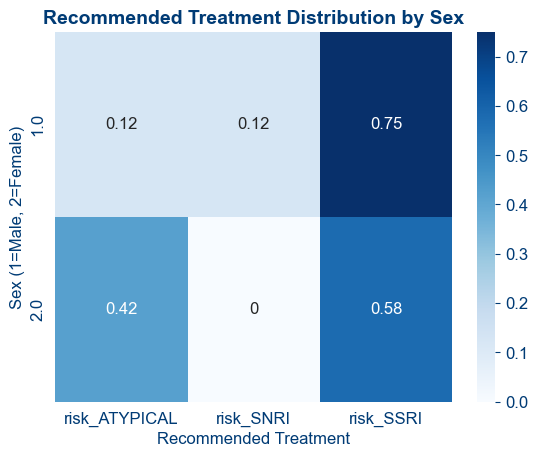

In [3982]:
import seaborn as sns
import matplotlib.pyplot as plt

#create a heatmap plot for treatment distribution by sex
plot_df = X_val.copy()
plot_df["recommended"] = risk_df["recommended_treatment"]

heat = pd.crosstab(
    plot_df["RIAGENDR"],
    plot_df["recommended"],
    normalize="index"
)

sns.heatmap(heat, annot=True, cmap="Blues")

plt.title("Recommended Treatment Distribution by Sex")
plt.xlabel("Recommended Treatment")
plt.ylabel("Sex (1=Male, 2=Female)")
plt.show()

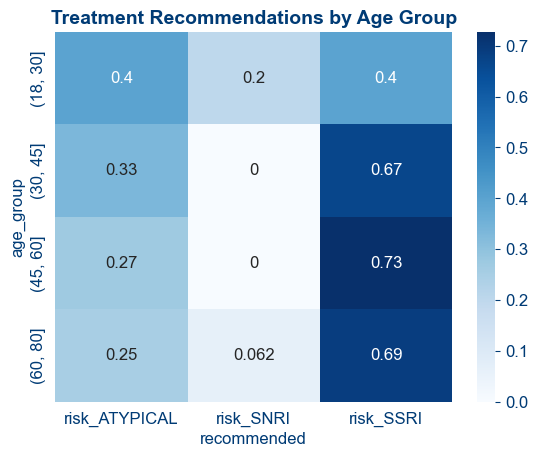

In [3983]:
#create a heatmap plot for treatment recommendations by age
plot_df["age_group"] = pd.cut(plot_df["RIDAGEYR"], bins=[18,30,45,60,80])

heat = pd.crosstab(
    plot_df["age_group"],
    plot_df["recommended"],
    normalize="index"
)

sns.heatmap(heat, annot=True, cmap="Blues")
plt.title("Treatment Recommendations by Age Group")
plt.show()

In [3984]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


INDFMPIR            0.617563
RIDAGEYR            0.464868
MCQ160A             0.253836
RIDRETH1            0.208303
RIAGENDR            0.176578
sleep_problem       0.133307
treatment           0.126090
SMQ020              0.121040
alcohol_user        0.105125
sleep_med           0.051292
MCQ160F             0.048528
MCQ010              0.046018
frequent_drinker    0.045669
heavy_drinker       0.036632
short_sleep         0.012917
dtype: float32


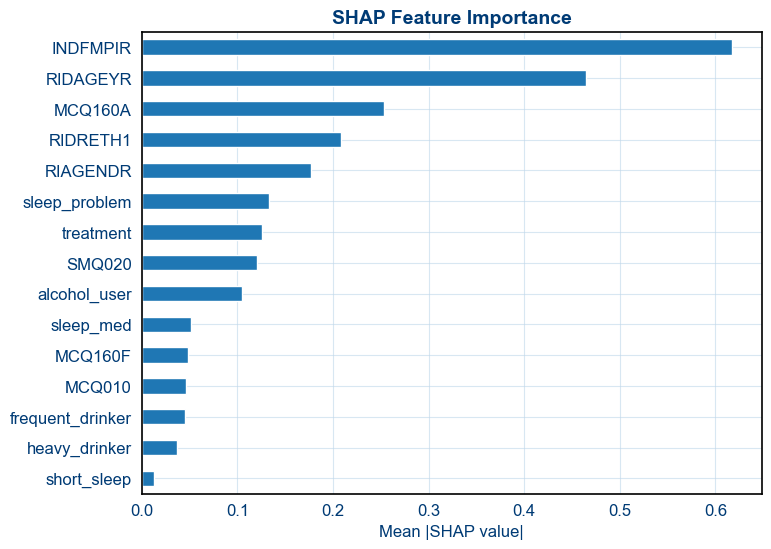

In [3985]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#convert the validation features into XGBoost DMatrix for evaluation
dm_val = xgb.DMatrix(X_val_outcome)

# SHAP values from XGBoost directly
shap_vals = outcome_model.get_booster().predict(dm_val, pred_contribs=True)

# Drop the last column (the bias term)
shap_df = pd.DataFrame(
    shap_vals[:, :-1],
    columns=X_val_outcome.columns
)

# Mean absolute SHAP importance
importance = shap_df.abs().mean().sort_values(ascending=False)

print(importance)

# Plot
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("SHAP Feature Importance")
plt.xlabel("Mean |SHAP value|")
plt.show()

In [3986]:
i = 0  # choose a patient row

#selects SHAP values for a single patient row and sorts features by importance
patient_shap = shap_df.iloc[i].sort_values(key=np.abs, ascending=False)

#show
print(patient_shap)

RIDAGEYR            0.529563
MCQ160A            -0.416791
INDFMPIR            0.300147
RIDRETH1            0.211764
SMQ020             -0.172516
RIAGENDR            0.112932
alcohol_user        0.093070
treatment          -0.086493
sleep_problem      -0.074541
heavy_drinker      -0.057307
frequent_drinker   -0.050638
sleep_med           0.026075
MCQ010              0.025425
MCQ160F             0.012259
short_sleep        -0.001583
Name: 0, dtype: float32


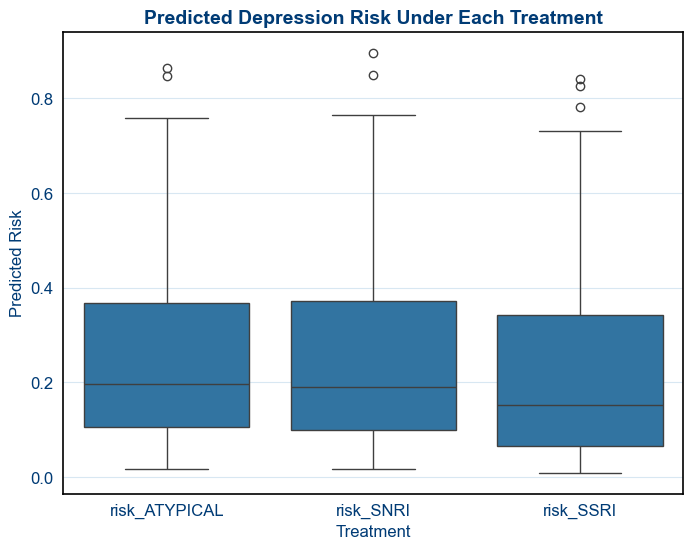

In [3987]:
import seaborn as sns
import matplotlib.pyplot as plt

#create boxplot to show predicted depression risk under each treatment
risk_long = risk_df.melt(
    value_vars=["risk_ATYPICAL", "risk_SNRI", "risk_SSRI"],
    var_name="treatment",
    value_name="risk"
)

plt.figure(figsize=(8,6))
sns.boxplot(x="treatment", y="risk", data=risk_long)
plt.title("Predicted Depression Risk Under Each Treatment")
plt.ylabel("Predicted Risk")
plt.xlabel("Treatment")
plt.show()

In [3988]:
# Build holdout dataframe for the standalone outcome model
X_test_outcome = X_test.copy()
X_test_outcome["treatment"] = T_test.values
y_test_outcome = y_test.values

In [3989]:
from sklearn.metrics import roc_auc_score, brier_score_loss

#evaluate
test_probs = outcome_model.predict_proba(X_test_outcome)[:, 1]

#show
print("Test AUROC:", roc_auc_score(y_test_outcome, test_probs))
print("Test Brier:", brier_score_loss(y_test_outcome, test_probs))

Test AUROC: 0.6599086236436322
Test Brier: 0.16433278226858714


In [3990]:
#create a copy of the test features for Atypical treatment scenario
X_test_t0 = X_test.copy()

#create a copy of the test features for SNRI treatment scenario
X_test_t1 = X_test.copy()

#create a copy of the test features for SSRI treatment scenario
X_test_t2 = X_test.copy()

#sets treatment to atypical for all patients to simulate that scenario
X_test_t0["treatment"] = 0   # ATYPICAL

#sets treatment to SNRI for all patients to simulate that scenario
X_test_t1["treatment"] = 1   # SNRI

#sets treatment to SSRI for all patients to simulate that scenario
X_test_t2["treatment"] = 2   # SSRI


#evaluates each if they received atypical - SSRI
risk_ATYPICAL_test = outcome_model.predict_proba(X_test_t0)[:, 1]
risk_SNRI_test = outcome_model.predict_proba(X_test_t1)[:, 1]
risk_SSRI_test = outcome_model.predict_proba(X_test_t2)[:, 1]

In [3991]:
#create a risk matrix
risk_test_df = pd.DataFrame({
    "risk_ATYPICAL": risk_ATYPICAL_test,
    "risk_SNRI": risk_SNRI_test,
    "risk_SSRI": risk_SSRI_test
})

print(risk_test_df.describe())

       risk_ATYPICAL   risk_SNRI   risk_SSRI
count     257.000000  257.000000  257.000000
mean        0.258718    0.258750    0.228490
std         0.186769    0.190008    0.187941
min         0.023353    0.021259    0.007246
25%         0.099574    0.095241    0.072519
50%         0.211623    0.197567    0.171422
75%         0.365552    0.393533    0.359234
max         0.806432    0.746674    0.722812


In [3992]:
#creates a new column assigning each patient the treatment with lowest predicted risk
risk_test_df["recommended_treatment"] = risk_test_df.idxmin(axis=1)

print(risk_test_df["recommended_treatment"].value_counts(normalize=True))

recommended_treatment
risk_SSRI        0.677043
risk_ATYPICAL    0.264591
risk_SNRI        0.058366
Name: proportion, dtype: float64


In [3993]:
# Predicted risk under the treatment the patient actually received
observed_risk_test = outcome_model.predict_proba(X_test_outcome)[:, 1]

# Predicted risk under the model-recommended treatment
recommended_risk_test = []

for i in range(len(X_test)):
    rec = risk_test_df["recommended_treatment"].iloc[i]
    recommended_risk_test.append(risk_test_df.loc[i, rec])

import numpy as np
recommended_risk_test = np.array(recommended_risk_test)

print("Mean observed risk (test):", observed_risk_test.mean())
print("Mean recommended risk (test):", recommended_risk_test.mean())
print("Absolute risk reduction (test):", observed_risk_test.mean() - recommended_risk_test.mean())

Mean observed risk (test): 0.23873347
Mean recommended risk (test): 0.21597002
Absolute risk reduction (test): 0.022763446


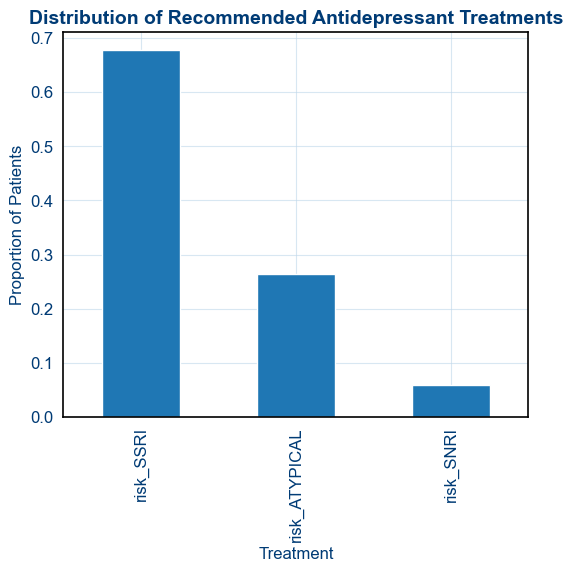

In [3994]:
#Treatment Recommendation Distribution
#shows how often each antidepressant is recommended
rec = risk_test_df["recommended_treatment"].value_counts(normalize=True)

plt.figure(figsize=(6,5))
rec.plot(kind="bar")

plt.title("Distribution of Recommended Antidepressant Treatments")
plt.ylabel("Proportion of Patients")
plt.xlabel("Treatment")

plt.show()

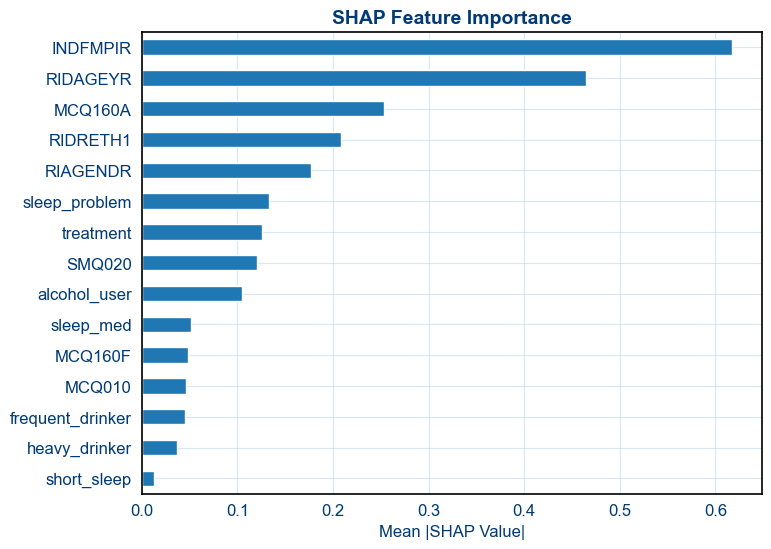

In [3995]:
#SHAP Feature Importance
#Global feature importance using SHAP values
#Socioeconomic status, age, comorbidities, and behavioral factors were the
#strongest predictors of depression risk
importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("SHAP Feature Importance")
plt.xlabel("Mean |SHAP Value|")
plt.show()

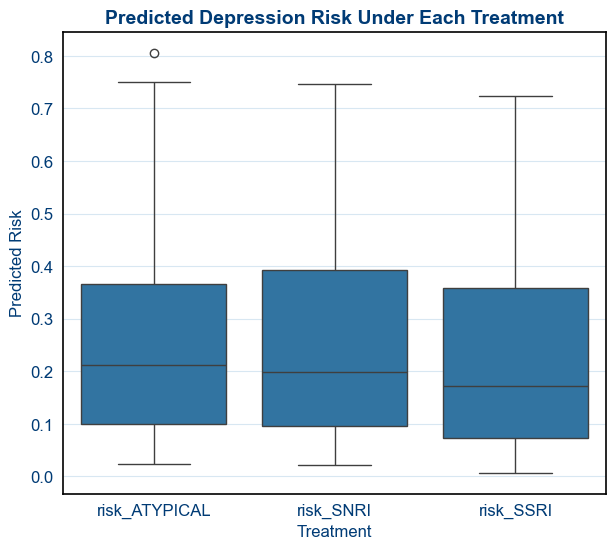

In [3996]:
#predicted risk by treatment
#Distribution of predicted depression risk under each antidepressant class
#SSRIs had the lowest average predicted risk across the test population
risk_long = risk_test_df.melt(
    value_vars=["risk_ATYPICAL","risk_SNRI","risk_SSRI"],
    var_name="treatment",
    value_name="risk"
)

plt.figure(figsize=(7,6))

sns.boxplot(
    x="treatment",
    y="risk",
    data=risk_long
)

plt.title("Predicted Depression Risk Under Each Treatment")
plt.ylabel("Predicted Risk")
plt.xlabel("Treatment")

plt.show()

In [3997]:
#confidence interval for policy improvement
#should estimate a 95% confidence interval using bootstrap resampling
n_boot = 2000

#initialize an empty list to store the bootstrap estimates
policy_effects = []

#repeat the bootstrap n_boot times
for _ in range(n_boot):

    #generate a bootstrap sample of indices by randomly sampling with replacement
    idx = np.random.choice(
        len(observed_risk_test),
        len(observed_risk_test),
        replace=True
    )

    #compute the difference in average risk between observed treatment and
    #recommended treatment for the sampled data
    effect = (
        observed_risk_test[idx].mean()
        - recommended_risk_test[idx].mean()
    )

    #store the computed policy effect from this bootstrap iteration
    policy_effects.append(effect)

#convert the list of bootstrap effects into a NumPy array
policy_effects = np.array(policy_effects)

#calculate the lower bound of the 95% confidence interval (2.5 percentile)
ci_lower = np.percentile(policy_effects, 2.5)

#calculate the upper bound of the 95% confidence interval (97.5 percentile)
ci_upper = np.percentile(policy_effects, 97.5)

#print the estimate average improvement from using the recommended treatment
print("Policy improvement:", observed_risk_test.mean() - recommended_risk_test.mean())

#print the 95% confidence interval for the policy improvment estimate
print("95% CI:", ci_lower, ci_upper)

Policy improvement: 0.022763446
95% CI: 0.018163765 0.027736839


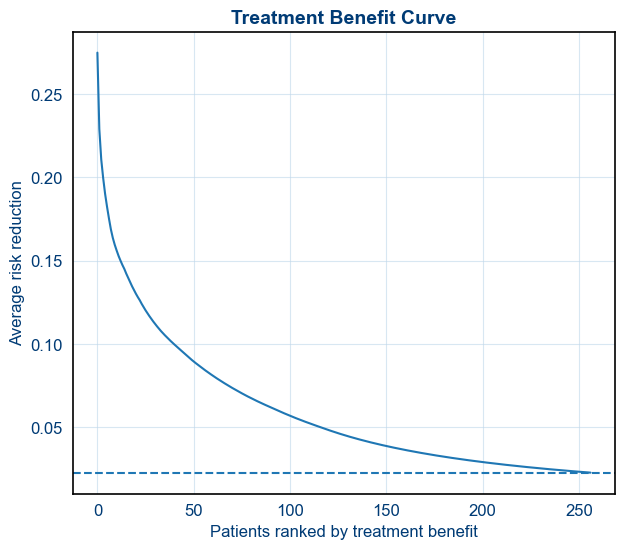

In [3998]:
#treatment benefit curve
# individual treatment benefit
benefit = observed_risk_test - recommended_risk_test

# sort largest benefit first
benefit_sorted = np.sort(benefit)[::-1]

# cumulative mean benefit
cum_benefit = np.cumsum(benefit_sorted) / np.arange(1, len(benefit_sorted)+1)

plt.figure(figsize=(7,6))

plt.plot(cum_benefit)

plt.axhline(
    benefit.mean(),
    linestyle="--"
)

plt.xlabel("Patients ranked by treatment benefit")
plt.ylabel("Average risk reduction")

plt.title("Treatment Benefit Curve")

plt.show()

#Figure 5. Treatment benefit curve.
#Patients were ranked by predicted improvement under the personalized treatment
#policy. The curve illustrates heterogeneity in treatment benefit, with a subset
#of patients predicted to experience larger reductions in depression risk.

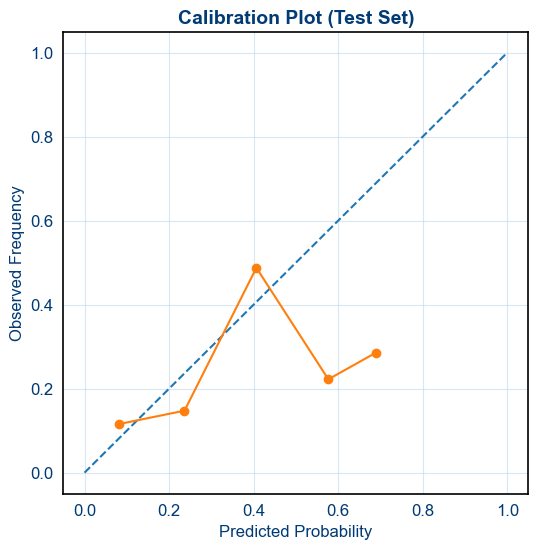

In [3999]:
from sklearn.calibration import calibration_curve

# get predicted probabilities from test set
test_probs = outcome_model.predict_proba(X_test_outcome)[:,1]

# compute calibration curve
prob_true, prob_pred = calibration_curve(
    y_test_outcome,
    test_probs,
    n_bins=6
)

plt.figure(figsize=(6,6))

# perfect calibration line
plt.plot([0,1],[0,1], linestyle="--")

# model calibration
plt.plot(prob_pred, prob_true, marker="o")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")

plt.title("Calibration Plot (Test Set)")

plt.show()

In [4000]:
#MODEL PERFORMANCE SUMMARY
table = pd.DataFrame({
    "Metric": [
        "AUROC",
        "Brier Score",
        "Mean Observed Risk",
        "Mean Recommended Risk",
        "Absolute Risk Reduction",
        "95% CI Lower",
        "95% CI Upper"
    ],
    "Validation": [
        0.6276,
        0.1758,
        None,
        None,
        None,
        None,
        None
    ],
    "Test": [
        0.6599,
        0.1643,
        0.2387,
        0.2160,
        0.0228,
        0.0180,
        0.0278
    ]
})

print(table)

                    Metric  Validation    Test
0                    AUROC      0.6276  0.6599
1              Brier Score      0.1758  0.1643
2       Mean Observed Risk         NaN  0.2387
3    Mean Recommended Risk         NaN  0.2160
4  Absolute Risk Reduction         NaN  0.0228
5             95% CI Lower         NaN  0.0180
6             95% CI Upper         NaN  0.0278


In [4001]:
# Create DMatrix from validation data
dm_val = xgb.DMatrix(X_val_outcome)

# Get SHAP contributions from XGBoost directly
shap_vals = outcome_model.get_booster().predict(dm_val, pred_contribs=True)

# Drop the last column (bias term)
shap_df = pd.DataFrame(
    shap_vals[:, :-1],
    columns=X_val_outcome.columns
)

# Mean absolute SHAP importance
importance = shap_df.abs().mean().sort_values(ascending=False)

print(importance)

INDFMPIR            0.617563
RIDAGEYR            0.464868
MCQ160A             0.253836
RIDRETH1            0.208303
RIAGENDR            0.176578
sleep_problem       0.133307
treatment           0.126090
SMQ020              0.121040
alcohol_user        0.105125
sleep_med           0.051292
MCQ160F             0.048528
MCQ010              0.046018
frequent_drinker    0.045669
heavy_drinker       0.036632
short_sleep         0.012917
dtype: float32


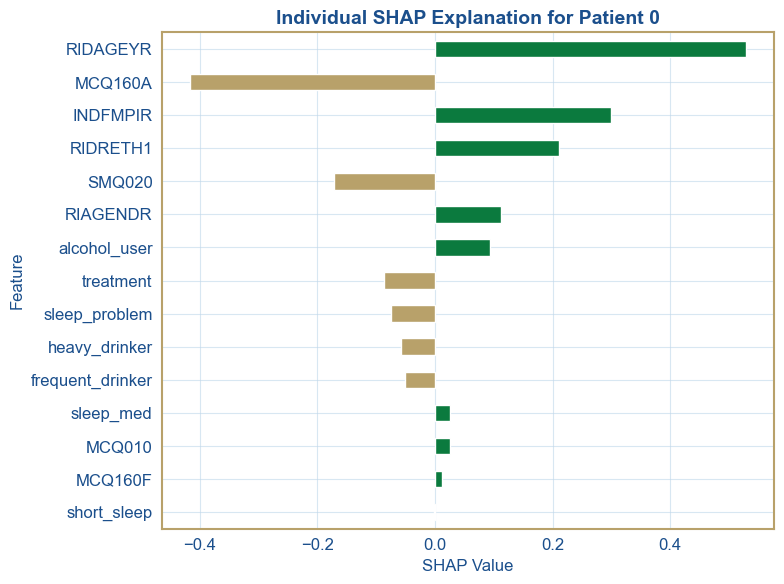

In [4002]:
#create an individual shap plot
patient_idx = 0

patient_shap = shap_df.iloc[patient_idx].sort_values(key=np.abs, ascending=True)

plt.figure(figsize=(8, 6))

patient_shap.plot(
    kind="barh",
    color=["#0B7A3E" if v > 0 else "#B8A16A" for v in patient_shap]
)

plt.title("Individual SHAP Explanation for Patient 0", color="#1B4F8C", fontsize=14)
plt.xlabel("SHAP Value", color="#1B4F8C")
plt.ylabel("Feature", color="#1B4F8C")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#B8A16A")
    spine.set_linewidth(1.5)

ax.tick_params(colors="#1B4F8C")

plt.tight_layout()
plt.show()

In [4003]:
sns.set_style("whitegrid")

# Main paper color from Overleaf
PAPER_BLUE = "#004C97"

# Variations of the same blue
BLUE_DARK   = "#003B75"
BLUE_MAIN   = "#004C97"
BLUE_MEDIUM = "#2E6FAF"
BLUE_LIGHT  = "#6FA3D2"
BLUE_PALE   = "#BFD7EA"

BLUE_PALETTE_3 = [BLUE_DARK, BLUE_MAIN, BLUE_MEDIUM]
BLUE_PALETTE_4 = [BLUE_DARK, BLUE_MAIN, BLUE_MEDIUM, BLUE_LIGHT]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": BLUE_MAIN,
    "axes.labelcolor": BLUE_DARK,
    "axes.titlecolor": BLUE_DARK,
    "xtick.color": BLUE_DARK,
    "ytick.color": BLUE_DARK,
    "text.color": BLUE_DARK,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.2,
    "grid.color": BLUE_PALE,
    "grid.alpha": 0.6,
    "font.size": 12,
    "legend.frameon": False
})

label_map = {0: "Atypical", 1: "SNRI", 2: "SSRI"}

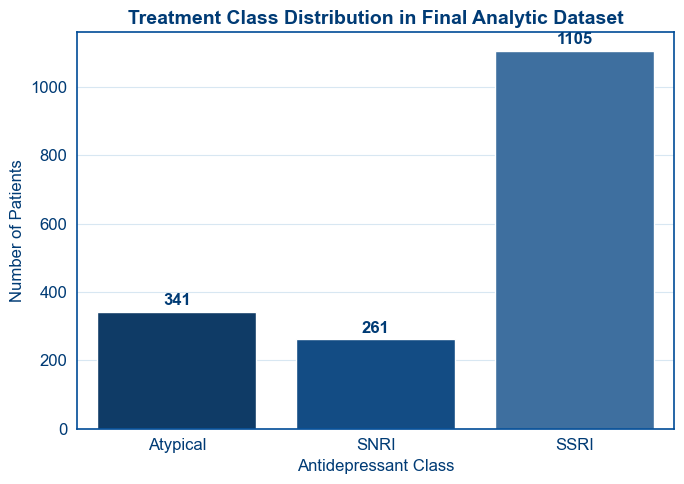

In [4004]:
#create a barplot showing treatment class distribution
treat_counts = model_df["treatment"].value_counts().sort_index()
treat_counts.index = treat_counts.index.map(label_map)

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x=treat_counts.index,
    y=treat_counts.values,
    hue=treat_counts.index,
    palette=BLUE_PALETTE_3,
    legend=False
)

for i, v in enumerate(treat_counts.values):
    ax.text(i, v + 20, f"{v}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("Treatment Class Distribution in Final Analytic Dataset")
plt.xlabel("Antidepressant Class")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("treatment_distribution_blue.png", dpi=300, bbox_inches="tight")
plt.show()

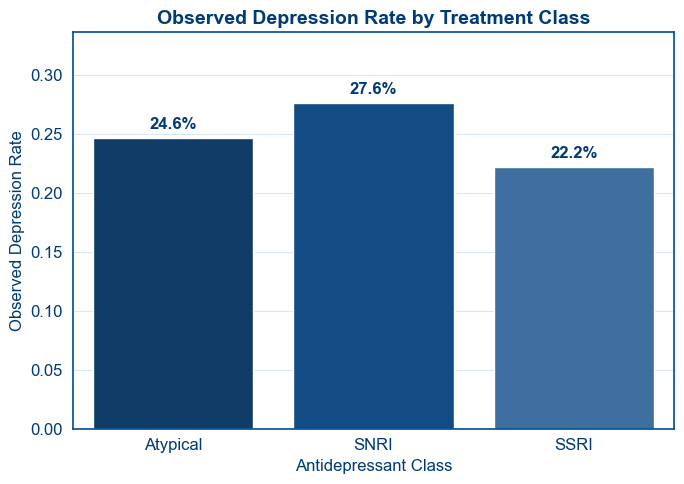

In [4005]:
#create a barplot showing observed depression rate by treatment class
raw_rates = model_df.groupby("treatment")["DEPRESSED"].mean().sort_index()
raw_rates.index = raw_rates.index.map(label_map)

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x=raw_rates.index,
    y=raw_rates.values,
    hue=raw_rates.index,
    palette=BLUE_PALETTE_3,
    legend=False
)

for i, v in enumerate(raw_rates.values):
    ax.text(i, v + 0.008, f"{v:.1%}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("Observed Depression Rate by Treatment Class")
plt.xlabel("Antidepressant Class")
plt.ylabel("Observed Depression Rate")
plt.ylim(0, max(raw_rates.values) + 0.06)
plt.tight_layout()
plt.savefig("observed_depression_rate_blue.png", dpi=300, bbox_inches="tight")
plt.show()

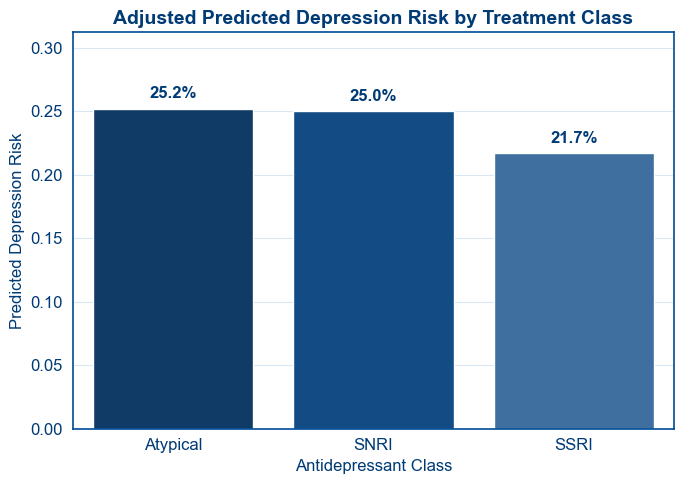

In [4006]:
#create a barplot showing adjusted predicted depressed risk by treatment class
adjusted_risks = pd.Series({
    "Atypical": 0.252,
    "SNRI": 0.250,
    "SSRI": 0.217
})

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x=adjusted_risks.index,
    y=adjusted_risks.values,
    hue=adjusted_risks.index,
    palette=BLUE_PALETTE_3,
    legend=False
)

for i, v in enumerate(adjusted_risks.values):
    ax.text(i, v + 0.008, f"{v:.1%}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("Adjusted Predicted Depression Risk by Treatment Class")
plt.xlabel("Antidepressant Class")
plt.ylabel("Predicted Depression Risk")
plt.ylim(0, max(adjusted_risks.values) + 0.06)
plt.tight_layout()
plt.savefig("adjusted_predicted_risk_blue.png", dpi=300, bbox_inches="tight")
plt.show()

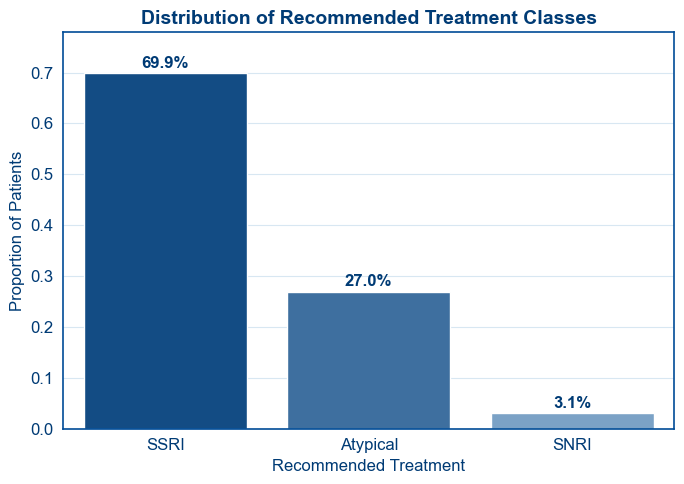

In [4007]:
#create a distribution plot to show distribution of recommended treatment classes
rec_dist = pd.Series({
    "SSRI": 0.699219,
    "Atypical": 0.269531,
    "SNRI": 0.031250
})

plt.figure(figsize=(7,5))
ax = sns.barplot(
    x=rec_dist.index,
    y=rec_dist.values,
    hue=rec_dist.index,
    palette=[BLUE_MAIN, BLUE_MEDIUM, BLUE_LIGHT],
    legend=False
)

for i, v in enumerate(rec_dist.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("Distribution of Recommended Treatment Classes")
plt.xlabel("Recommended Treatment")
plt.ylabel("Proportion of Patients")
plt.ylim(0, max(rec_dist.values) + 0.08)
plt.tight_layout()
plt.savefig("recommended_treatment_distribution_blue.png", dpi=300, bbox_inches="tight")
plt.show()

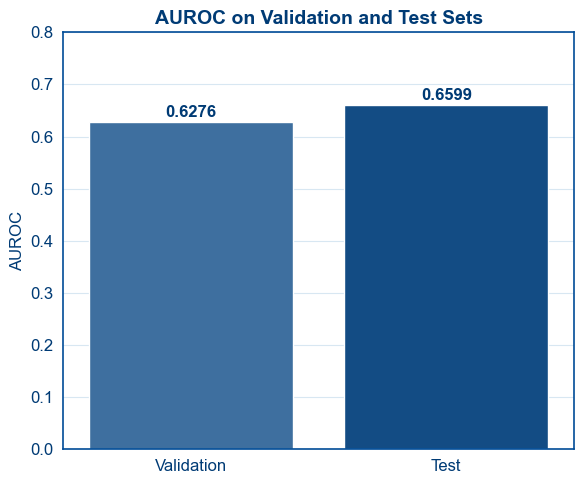

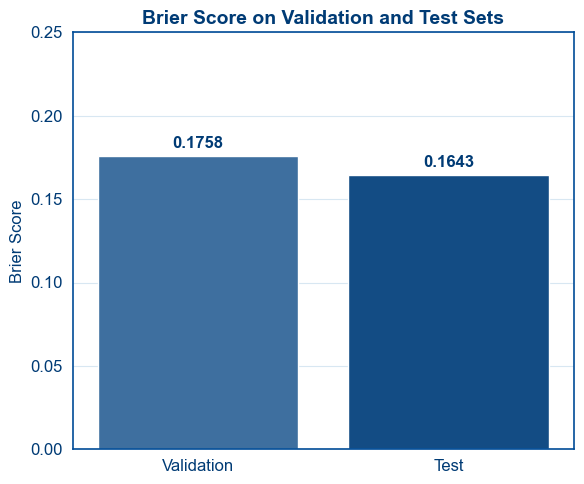

In [4008]:
#create barplot to show differences in evaluation scores between validation and test
#sets
perf_df = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "AUROC": [0.6276, 0.6599],
    "Brier Score": [0.1758, 0.1643]
})

# AUROC
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=perf_df,
    x="Dataset",
    y="AUROC",
    hue="Dataset",
    palette=[BLUE_MEDIUM, BLUE_MAIN],
    legend=False
)

for i, v in enumerate(perf_df["AUROC"]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("AUROC on Validation and Test Sets")
plt.ylabel("AUROC")
plt.xlabel("")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig("auroc_validation_test_blue.png", dpi=300, bbox_inches="tight")
plt.show()

# Brier Score
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=perf_df,
    x="Dataset",
    y="Brier Score",
    hue="Dataset",
    palette=[BLUE_MEDIUM, BLUE_MAIN],
    legend=False
)

for i, v in enumerate(perf_df["Brier Score"]):
    ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("Brier Score on Validation and Test Sets")
plt.ylabel("Brier Score")
plt.xlabel("")
plt.ylim(0, 0.25)
plt.tight_layout()
plt.savefig("brier_validation_test_blue.png", dpi=300, bbox_inches="tight")
plt.show()

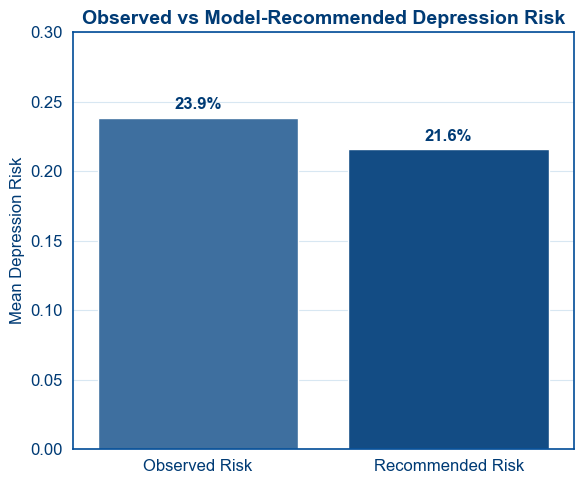

In [4009]:
#create a barplot to show observed vs. model recommended depression risk
policy_df = pd.DataFrame({
    "Metric": ["Observed Risk", "Recommended Risk"],
    "Risk": [0.2387, 0.2160]
})

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=policy_df,
    x="Metric",
    y="Risk",
    hue="Metric",
    palette=[BLUE_MEDIUM, BLUE_MAIN],
    legend=False
)

for i, v in enumerate(policy_df["Risk"]):
    ax.text(i, v + 0.006, f"{v:.1%}", ha="center", fontweight="bold", color=BLUE_DARK)

plt.title("Observed vs Model-Recommended Depression Risk")
plt.ylabel("Mean Depression Risk")
plt.xlabel("")
plt.ylim(0, 0.30)
plt.tight_layout()
plt.savefig("observed_vs_recommended_risk_blue.png", dpi=300, bbox_inches="tight")
plt.show()

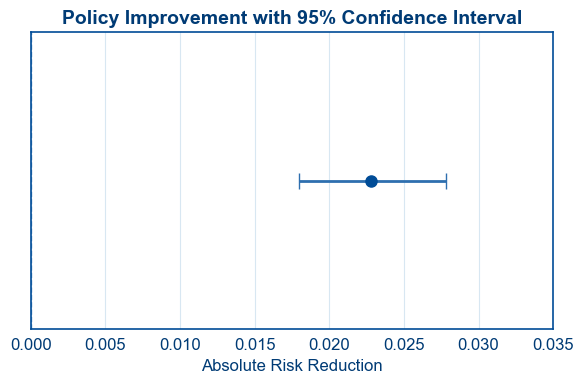

In [4010]:
#policy improvement with confidence interval plot
arr = 0.0228
ci_lower = 0.0180
ci_upper = 0.0278

plt.figure(figsize=(6,4))
plt.errorbar(
    x=[arr],
    y=[0],
    xerr=[[arr - ci_lower], [ci_upper - arr]],
    fmt='o',
    markersize=8,
    capsize=6,
    color=BLUE_MAIN,
    ecolor=BLUE_MEDIUM,
    elinewidth=2
)

plt.axvline(0, linestyle="--", linewidth=1, color=BLUE_LIGHT)
plt.yticks([])
plt.xlabel("Absolute Risk Reduction")
plt.title("Policy Improvement with 95% Confidence Interval")
plt.xlim(0, 0.035)
plt.tight_layout()
plt.savefig("policy_improvement_ci_blue.png", dpi=300, bbox_inches="tight")
plt.show()

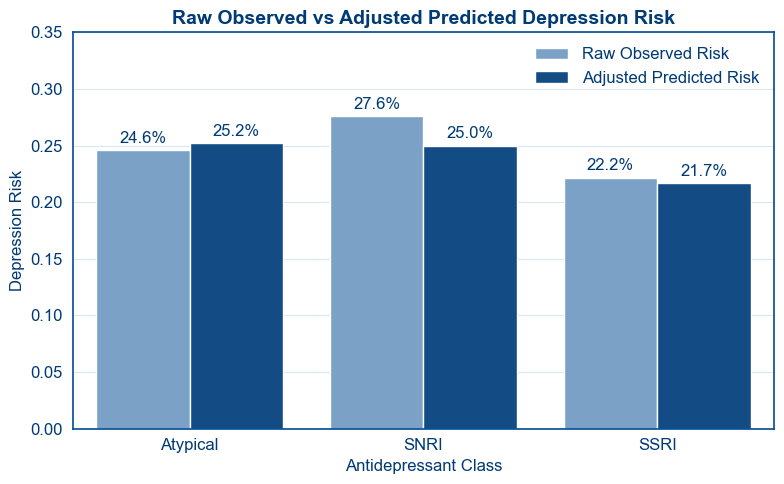

In [4011]:
#barplot to show observed risk vs. adjusted prediction depression risk
compare_df = pd.DataFrame({
    "Treatment": ["Atypical", "SNRI", "SSRI"],
    "Raw Observed Risk": [0.246334, 0.275862, 0.221719],
    "Adjusted Predicted Risk": [0.252, 0.250, 0.217]
})

compare_long = compare_df.melt(
    id_vars="Treatment",
    var_name="Risk Type",
    value_name="Risk"
)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=compare_long,
    x="Treatment",
    y="Risk",
    hue="Risk Type",
    palette=[BLUE_LIGHT, BLUE_MAIN]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in container.datavalues], padding=3, color=BLUE_DARK)

plt.title("Raw Observed vs Adjusted Predicted Depression Risk")
plt.xlabel("Antidepressant Class")
plt.ylabel("Depression Risk")
plt.ylim(0, 0.35)
plt.legend(title="")
plt.tight_layout()
plt.savefig("raw_vs_adjusted_risk_blue.png", dpi=300, bbox_inches="tight")
plt.show()

In [4012]:
#change visualizations color scheme to same blue as in overleaf paper
sns.set_style("whitegrid")

# --- Your color system ---
PAPER_BLUE = "#004C97"

BLUE_DARK   = "#003B75"
BLUE_MAIN   = "#004C97"
BLUE_MEDIUM = "#2E6FAF"
BLUE_LIGHT  = "#6FA3D2"
BLUE_PALE   = "#BFD7EA"

BLUE_PALETTE_3 = [BLUE_DARK, BLUE_MAIN, BLUE_MEDIUM]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",   # <-- black outline
    "axes.labelcolor": BLUE_DARK,
    "axes.titlecolor": BLUE_DARK,
    "xtick.color": BLUE_DARK,
    "ytick.color": BLUE_DARK,
    "text.color": BLUE_DARK,
    "axes.titleweight": "bold",
    "axes.linewidth": 1.2,
    "grid.color": BLUE_PALE,
    "grid.alpha": 0.6,
    "font.size": 12,
    "legend.frameon": False
})

# --- Reshape data ---
risk_long = risk_test_df.melt(
    value_vars=["risk_ATYPICAL","risk_SNRI","risk_SSRI"],
    var_name="treatment",
    value_name="risk"
)

# Clean labels
risk_long["treatment"] = risk_long["treatment"].replace({
    "risk_ATYPICAL": "Atypical",
    "risk_SNRI": "SNRI",
    "risk_SSRI": "SSRI"
})

/var/folders/1b/5ctp1g0d4gj274vf7qb8k0g40000gn/T/ipykernel_80845/2550542589.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


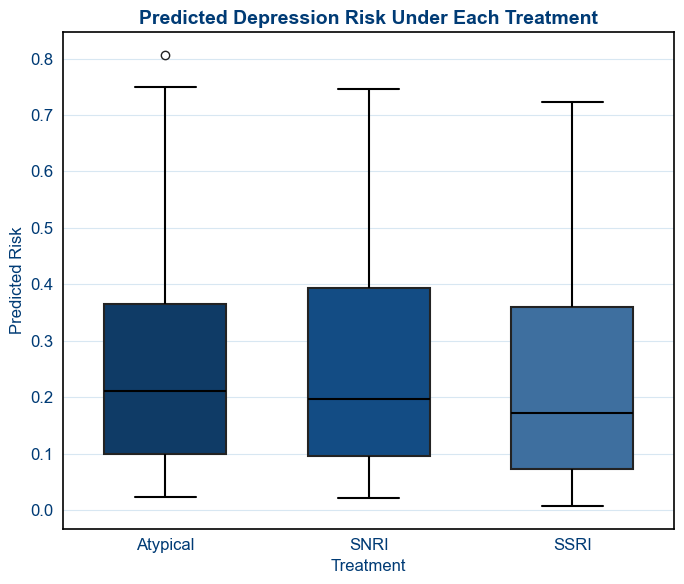

In [4013]:
#boxplot for predicted depression risk under each treatment
plt.figure(figsize=(7,6))

ax = sns.boxplot(
    data=risk_long,
    x="treatment",
    y="risk",
    palette=BLUE_PALETTE_3,
    width=0.6,
    linewidth=1.5
)

# --- Force black outlines on EVERYTHING ---
for artist in ax.artists:
    artist.set_edgecolor("black")

for line in ax.lines:
    line.set_color("black")

# --- Labels ---
plt.title("Predicted Depression Risk Under Each Treatment")
plt.ylabel("Predicted Risk")
plt.xlabel("Treatment")

plt.tight_layout()

plt.savefig("Predicted_Depression_Boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

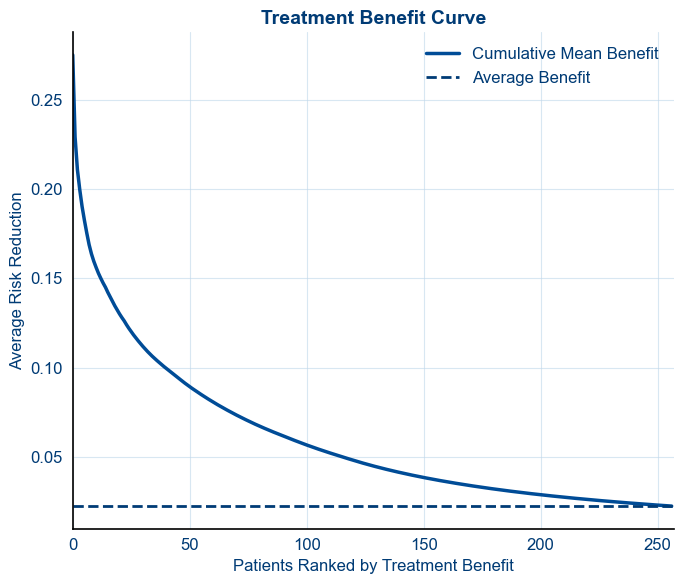

In [4014]:
#create treatment benefit curve plot
benefit = observed_risk_test - recommended_risk_test

benefit_sorted = np.sort(benefit)[::-1]

cum_benefit = np.cumsum(benefit_sorted) / np.arange(1, len(benefit_sorted)+1)

# --- Plot ---
plt.figure(figsize=(7,6))

plt.plot(
    cum_benefit,
    color=BLUE_MAIN,
    linewidth=2.5,
    label="Cumulative Mean Benefit"
)

# --- Average benefit line ---
plt.axhline(
    benefit.mean(),
    color=BLUE_DARK,
    linestyle="--",
    linewidth=2,
    label="Average Benefit"
)

# --- Labels ---
plt.xlabel("Patients Ranked by Treatment Benefit")
plt.ylabel("Average Risk Reduction")
plt.title("Treatment Benefit Curve")

# --- Optional: nicer x-axis scaling ---
plt.xlim(0, len(cum_benefit))

# --- Legend ---
plt.legend()

# --- Clean look ---
sns.despine()

plt.tight_layout()

plt.savefig("Treatment_Benefit_Curve.png", dpi=300, bbox_inches="tight")

plt.show()

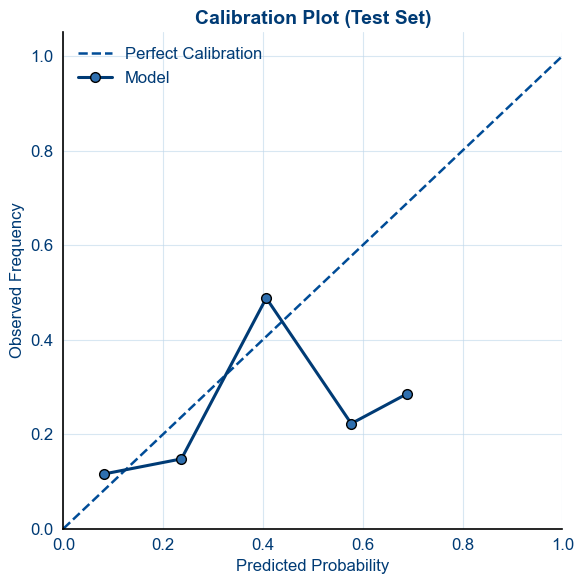

In [4015]:
#create calibration plot
# --- Plot ---
plt.figure(figsize=(6,6))

# Perfect calibration line
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color=BLUE_MAIN,
    linewidth=1.8,
    label="Perfect Calibration"
)

# Model calibration curve
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    markersize=7,
    linewidth=2.2,
    color=BLUE_DARK,
    markerfacecolor=BLUE_MEDIUM,
    markeredgecolor="black",
    label="Model"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Plot (Test Set)")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend()

sns.despine()

plt.tight_layout()

plt.savefig("Calibration_Plot.png", dpi=300, bbox_inches="tight")

plt.show()

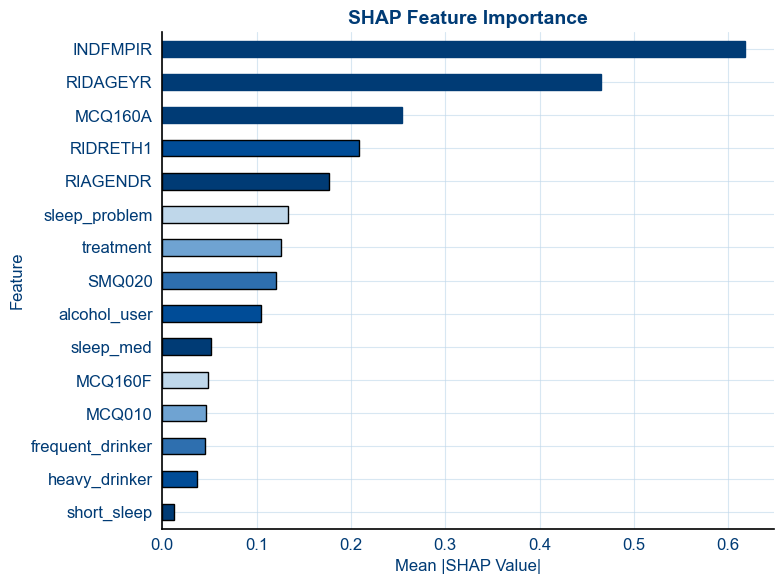

In [4016]:
#create shap feature importance plot
plt.figure(figsize=(8, 6))

# --- Gradient blue palette for bars ---
colors = [BLUE_DARK, BLUE_MAIN, BLUE_MEDIUM, BLUE_LIGHT, BLUE_PALE]

# Expand palette to match number of features
palette = colors * (len(importance) // len(colors) + 1)

# --- Plot ---
ax = importance.sort_values().plot(
    kind="barh",
    color=palette[:len(importance)],
    edgecolor="black",     # black bar outlines
    linewidth=1.0
)

# --- Labels ---
plt.title("SHAP Feature Importance")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")

# --- Clean spines (keep black border) ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)

# --- Optional: emphasize top features visually ---
# (makes figure look more "publication grade")
for i, bar in enumerate(ax.patches):
    if i >= len(ax.patches) - 3:  # top 3 features
        bar.set_color(BLUE_DARK)

sns.despine(left=False, bottom=False)

plt.tight_layout()

plt.savefig("SHAP_Feature_Importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [4017]:
import os
print(os.getcwd())

/Users/melyndacelani/Desktop/Capstone_Data


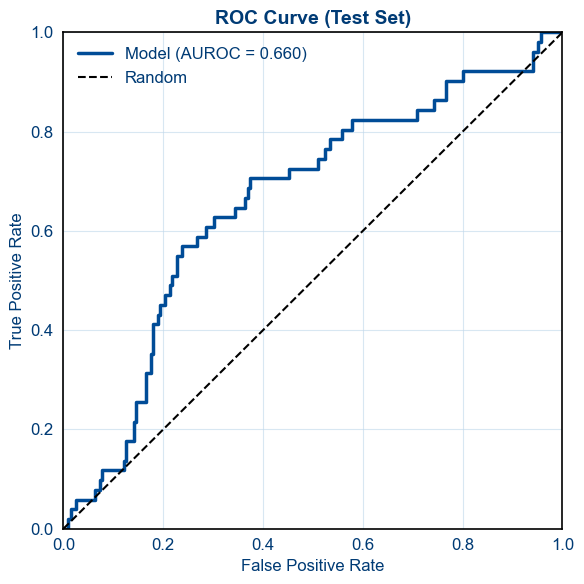

In [4018]:
#create roc curve plot 
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# predicted probabilities
y_probs = outcome_model.predict_proba(X_test_outcome)[:, 1]

# ROC pieces
fpr, tpr, thresholds = roc_curve(y_test_outcome, y_probs)
roc_auc = roc_auc_score(y_test_outcome, y_probs)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr, tpr,
    color=BLUE_MAIN,
    linewidth=2.5,
    label=f"Model (AUROC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.xlim(0, 1)
plt.ylim(0, 1)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)

plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.pdf", bbox_inches="tight")
plt.show()

In [4019]:
print("After antidepressant filter:", df_treatment.shape[0])

After antidepressant filter: 2085
